# Detecting and Correcting Spatial Bias in VGI Using Remote Sensing

**End-to-end reproducible pipeline** — from raw LiDAR point clouds to a statewide
map of OpenStreetMap (OSM) quality bias.

Volunteered Geographic Information (VGI) such as OpenStreetMap is highly accurate in
well-mapped urban areas but incomplete and stale in data-sparse regions. This notebook
reproduces the full analysis of the
[vgi-spatial-bias](https://github.com/rayford295/vgi-spatial-bias) project
(an [I-GUIDE Summer School 2026 project](https://i-guide.io/summer-school/summer-school-2026/summer-school-2026-projects/))
at its two working scales:

| Scale | Ground truth | Question answered |
|---|---|---|
| **Campus pilot** (2 × 2 km UIUC tile) | LiDAR + NAIP consensus | *Is OSM missing real objects, and where inside a city?* |
| **Statewide** (102 Illinois counties) | Census-normalized OSM internals | *Does OSM quality vary systematically with who lives there?* |
| **Second region** (2 × 2 km Colorado Springs) | NDVI+echo detection variant | *Does the method generalize?* |

**Research questions** (full framing in
[`docs/PROJECT_DESCRIPTION.md`](https://github.com/rayford295/vgi-spatial-bias/blob/main/docs/PROJECT_DESCRIPTION.md)):

1. How does VGI accuracy and completeness vary across geographic and socioeconomic contexts?
2. Can remote sensing detect discrepancies in VGI data such as roads and buildings?
3. How can we develop scalable (AI) approaches to automatically improve VGI quality in data-sparse regions?

**Pipeline at a glance**

```
 LiDAR (USGS 3DEP) ──► Stage 1  classical detection      (DTM, buildings, trees)
                   └─► Stage 2  DGCNN semantic segmentation   [optional, GPU-friendly]
 NAIP (RGBN)       ──► Stage 3  optical land cover, LiDAR-fused paved layer
 OSM 2019/2026     ──► Stage 4  buildings: completeness, bias map, temporal validation
                   └─► Stage 5  roads: NAIP support, 2019→2026 evolution, major-roads subset
 OSM statewide + Census ─► Stage 6  102-county urban→rural bias gradient
```

**How to run.** Execute top-to-bottom. Every stage is a thin wrapper around a script in
[`src/`](https://github.com/rayford295/vgi-spatial-bias/tree/main/src) — the notebook
explains *what* each stage does and *why*, runs it, then displays the outputs. All
heavy inputs are downloaded automatically (≈ 1 GB on first run, cached afterwards).
Stage 2 (deep learning) is optional and controlled by the `RUN_DL` flag in the
configuration cell. Designed to run unmodified on the I-GUIDE JupyterHub, a laptop,
or any Linux/macOS machine with Python ≥ 3.10.

| Stage | Approx. runtime |
|---|---|
| Data download (first run only) | 5–15 min (network-bound) |
| 1 · Classical detection | ~3 min |
| 2 · DGCNN segmentation *(optional)* | 10–15 min on GPU/Apple-MPS, ~1–2 h on CPU |
| 3 · NAIP segmentation | ~2 min |
| 4 · Buildings comparison + temporal | ~3 min |
| 5 · Roads comparison + evolution | ~4 min |
| 6 · Statewide bias analysis | ~3 min |
| 7 · Correction pipeline | ~15 min (U-Net on GPU/MPS) |
| 8 · Colorado Springs region | ~8 min |

## 1 · Environment setup

The notebook needs the **whole repository** (scripts, campus OSM subsets, docs), not
just this file. If you launched it from a repo checkout, nothing happens here; if you
only have the notebook (e.g. downloaded from an I-GUIDE knowledge element), the cell
clones the repository next to it and switches into it. It then installs the Python
dependencies pinned in `requirements.txt`.

In [1]:
import os, sys, subprocess

REPO_URL = "https://github.com/rayford295/vgi-spatial-bias.git"

if os.path.exists("src/prepare_data.py"):            # already inside a checkout
    REPO = os.getcwd()
else:                                                 # standalone notebook -> clone
    REPO = os.path.abspath("vgi-spatial-bias")
    if not os.path.exists(REPO):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO], check=True)
    os.chdir(REPO)

print("repository:", REPO)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
               check=False)
print("dependencies ready")

repository: /Users/yifn/Downloads/uiuc_campus_lidar


dependencies ready


### Configuration & helpers

`RUN_DL` toggles the deep-learning stage (everything else works without it — the
classical pipeline already provides the ground-truth footprints). The three helpers
keep every stage cell identical in shape: `run()` executes a pipeline script and fails
loudly if it fails, `show()` displays saved figures, `jshow()` pretty-prints a JSON
summary.

In [2]:
%matplotlib inline
import io, json
from IPython.display import Image, display

RUN_DL = False          # set True to train the DGCNN segmentation model (GPU recommended)
RUN_LEARNED = True      # train the Stage-7 correction U-Net (~10 min GPU/MPS; set False on CPU-only)

def run(*args):
    cmd = [sys.executable] + list(args)
    print("$ python", " ".join(args))
    r = subprocess.run(cmd, cwd=REPO)
    if r.returncode != 0:
        raise RuntimeError(f"step failed: {' '.join(args)}")

def show(*paths, width=950):
    """Display a saved figure, downscaled to keep the notebook light.

    The full-resolution originals live in results/ — this only affects the
    inline preview embedded in the notebook file."""
    from PIL import Image as PILImage
    for p in paths:
        img = PILImage.open(os.path.join(REPO, p))
        if img.width > 1400:
            img = img.resize((1400, round(img.height * 1400 / img.width)),
                             PILImage.LANCZOS)
        buf = io.BytesIO()
        img.convert("RGB").save(buf, "JPEG", quality=85)
        display(Image(data=buf.getvalue(), format="jpeg", width=width))

def jshow(path, drop=()):
    with open(os.path.join(REPO, path)) as f:
        d = json.load(f)
    print(json.dumps({k: v for k, v in d.items() if k not in drop}, indent=2))

## 2 · Data acquisition

`src/prepare_data.py` downloads and stages every external input **idempotently**
(re-running skips files that are already present). All paths land where the pipeline
scripts expect them, and all locations are gitignored.

| Input | Source | Size | Staged at |
|---|---|---|---|
| LiDAR, 4 × 1 km QL1 tiles (80.8 M pts) | [I-GUIDE dataset storage](https://storage.i-guide.io) | ~340 MB | `data/uiuc_campus/UIUC_campus_LiDAR_merged_2x2km.laz` (tiles merged on the fly) |
| NAIP 4-band imagery, ~0.7 m, EPSG:6350 | GitHub release [`campus-rs-2019`](https://github.com/rayford295/vgi-spatial-bias/releases/tag/campus-rs-2019) | ~480 MB | `data/uiuc_campus/NAIP_image.tif` |
| OSM 2019 statewide major roads (375,754 segments, county-joined) | GitHub release [`osm-il-2019`](https://github.com/rayford295/vgi-spatial-bias/releases/tag/osm-il-2019) | ~65 MB | `data/statewide_il/OSM_2019_Major_Roads/` |
| Census 2019: county areas, population, boundaries | census.gov static files | ~5 MB | `data/statewide_il/` |
| Colorado Springs: LiDAR (LAZ) + clipped NAIP | GitHub release [`colorado-springs-2019`](https://github.com/rayford295/vgi-spatial-bias/releases/tag/colorado-springs-2019) | ~330 MB | `data/colorado_springs/` (fetched by Stage 8) |

The small campus-extent OSM snapshots (`data/uiuc_campus/osm_*_20{19,26}.geojson`) are committed in
the repository, so the buildings/roads comparisons are reproducible byte-for-byte —
`src/fetch_osm_current.py` can refresh the "current" snapshot from the Overpass API if
you want to re-run the temporal validation against today's OSM instead of the archived
2026 snapshot.

**Why OSM 2019 and not current OSM as the subject?** The LiDAR and NAIP were flown in
2019. Comparing same-year data separates "OSM had not mapped it" from "it was not built
yet" — the 2026 snapshot is then used as *validation* (Stage 4) rather than as the
subject.

In [3]:
run("src/prepare_data.py")

$ python src/prepare_data.py
[lidar]
  already present: UIUC_campus_LiDAR_merged_2x2km.laz
[naip]
  already present: data/uiuc_campus/NAIP_image.tif
[statewide]
  already present: data/statewide_il/OSM_2019_IL_Major_Roads.zip
  already present: data/statewide_il/gaz_counties_17.txt
  already present: data/statewide_il/co-est2019.csv
  already present: data/statewide_il/cb_county.zip
[colorado]
  already present: data/colorado_springs/cs_lidar_2km.laz
  already present: data/colorado_springs/NAIP_image.tif
data ready


## 3 · Stage 1 — Classical LiDAR detection (the RS ground truth)

`src/classical_detection.py` turns the raw point cloud into objective, OSM-independent
reference layers:

1. **Ground / DTM** — morphological filtering of ground returns, then interpolation to a
   0.5 m bare-earth raster. Everything else is measured as *height above ground*.
2. **Building instances** — non-ground, low-vegetation-index, planar clusters →
   footprint polygons with `area_m2` and `height_m` attributes.
3. **Individual trees** — canopy-height-model local maxima → tree tops with crown size.

The ASPRS classification that ships inside the LAZ is used only as a cross-check; the
detection itself is reproducible from geometry alone. Outputs go to
`results/uiuc_campus/detection/` (GeoJSON in WGS84 for GIS hand-off + diagnostic PNGs).

> **Why LiDAR as ground truth?** Airborne LiDAR measures 3-D structure directly —
> a building is a planar elevated surface regardless of how it looks in imagery or
> whether any volunteer has ever mapped it. Fused with NAIP (Stage 3), two independent
> sensors must agree before we call an OSM omission real.

In [4]:
run("src/classical_detection.py")

$ python src/classical_detection.py


/Users/yifn/Downloads/uiuc_campus_lidar/src/classical_detection.py:102: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  bmask = binary_closing(bmask, disk(2))
/Users/yifn/Downloads/uiuc_campus_lidar/src/classical_detection.py:103: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bmask = remove_small_holes(bmask, area_threshold=min_cells)


/Users/yifn/Downloads/uiuc_campus_lidar/src/classical_detection.py:104: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bmask = remove_small_objects(bmask, min_size=min_cells)


[1/5] rasterizing 80,849,096 pts -> 4000x4000 @ 0.5 m
[2/5] building DTM (nearest-fill of ground minima)
[3/5] detecting building instances
      -> 1312 buildings
[4/5] detecting individual trees (CHM local maxima + watershed crowns)
      -> 11777 trees
[5/5] summary
{
  "resolution_m": 0.5,
  "grid": [
    4000,
    4000
  ],
  "buildings": {
    "count": 1312,
    "total_footprint_m2": 943498.4,
    "median_height_m": 8.3,
    "tallest_m": 76.1
  },
  "trees": {
    "count": 11777,
    "median_height_m": 12.0,
    "tallest_m": 52.9,
    "median_crown_m2": 21.5
  }
}

Outputs in /Users/yifn/Downloads/uiuc_campus_lidar/results/uiuc_campus/detection


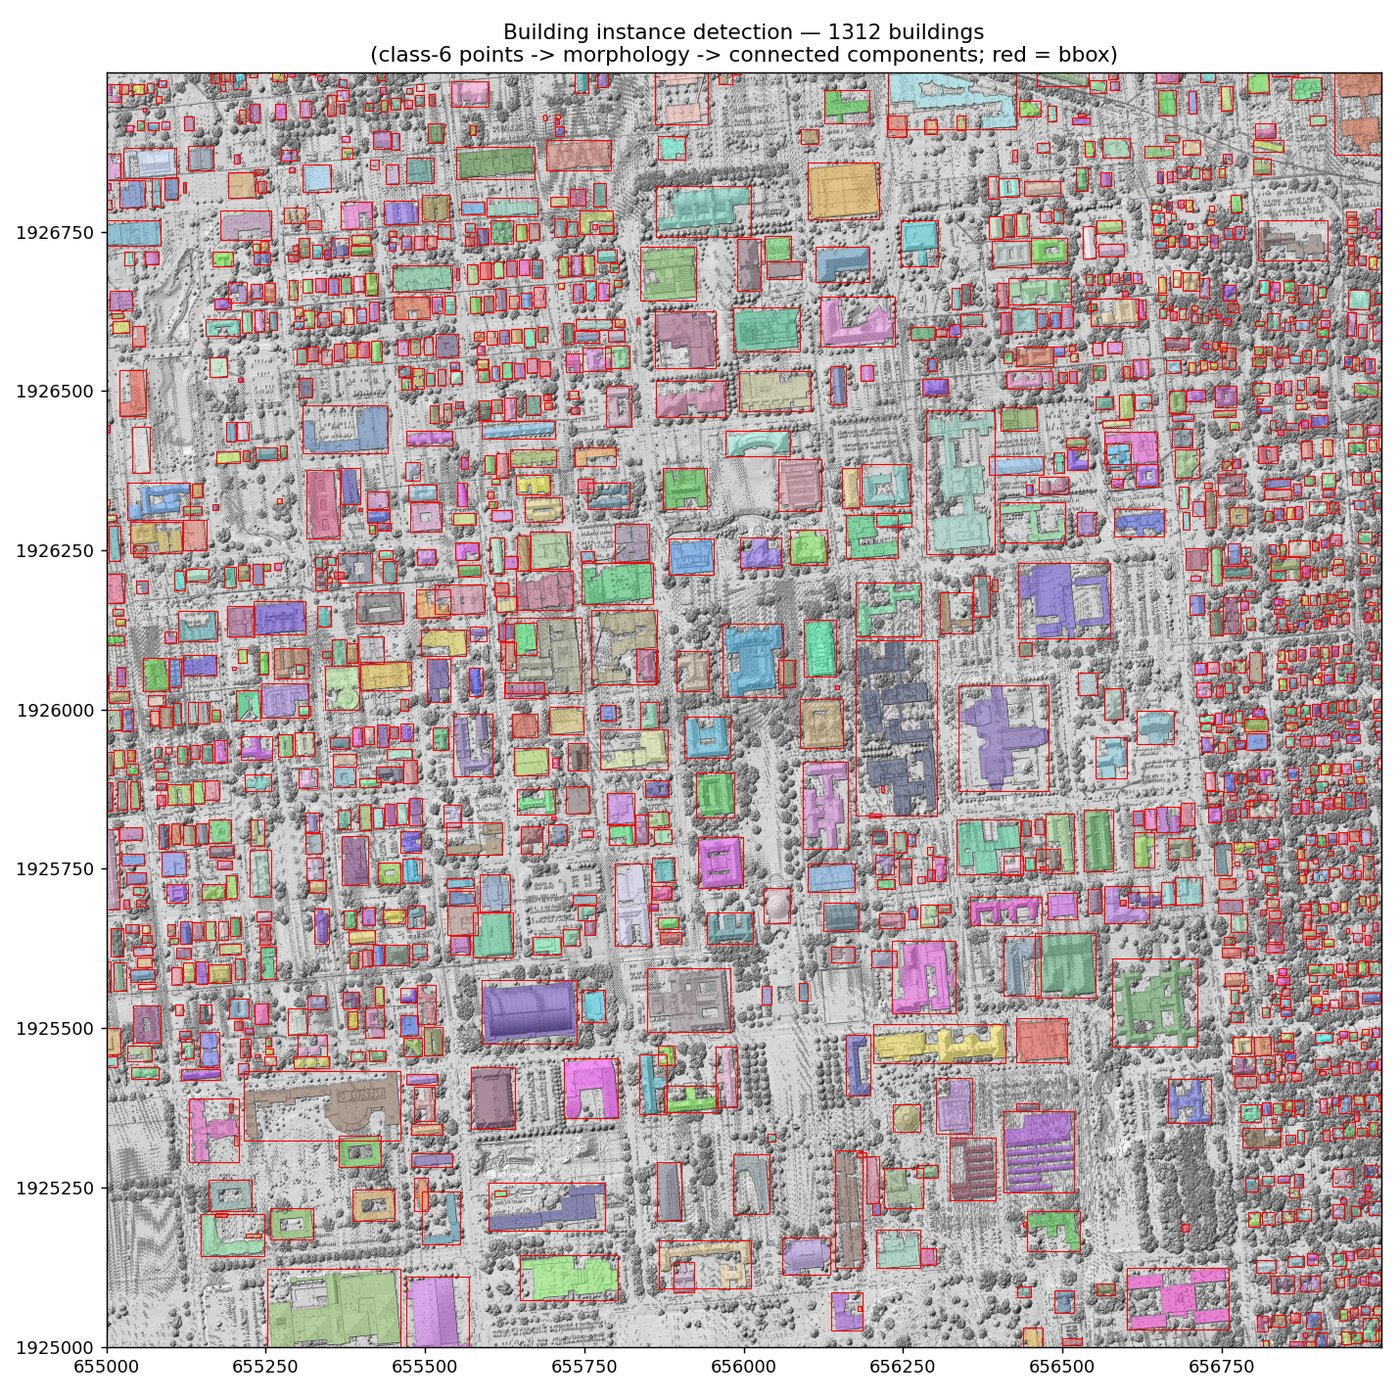

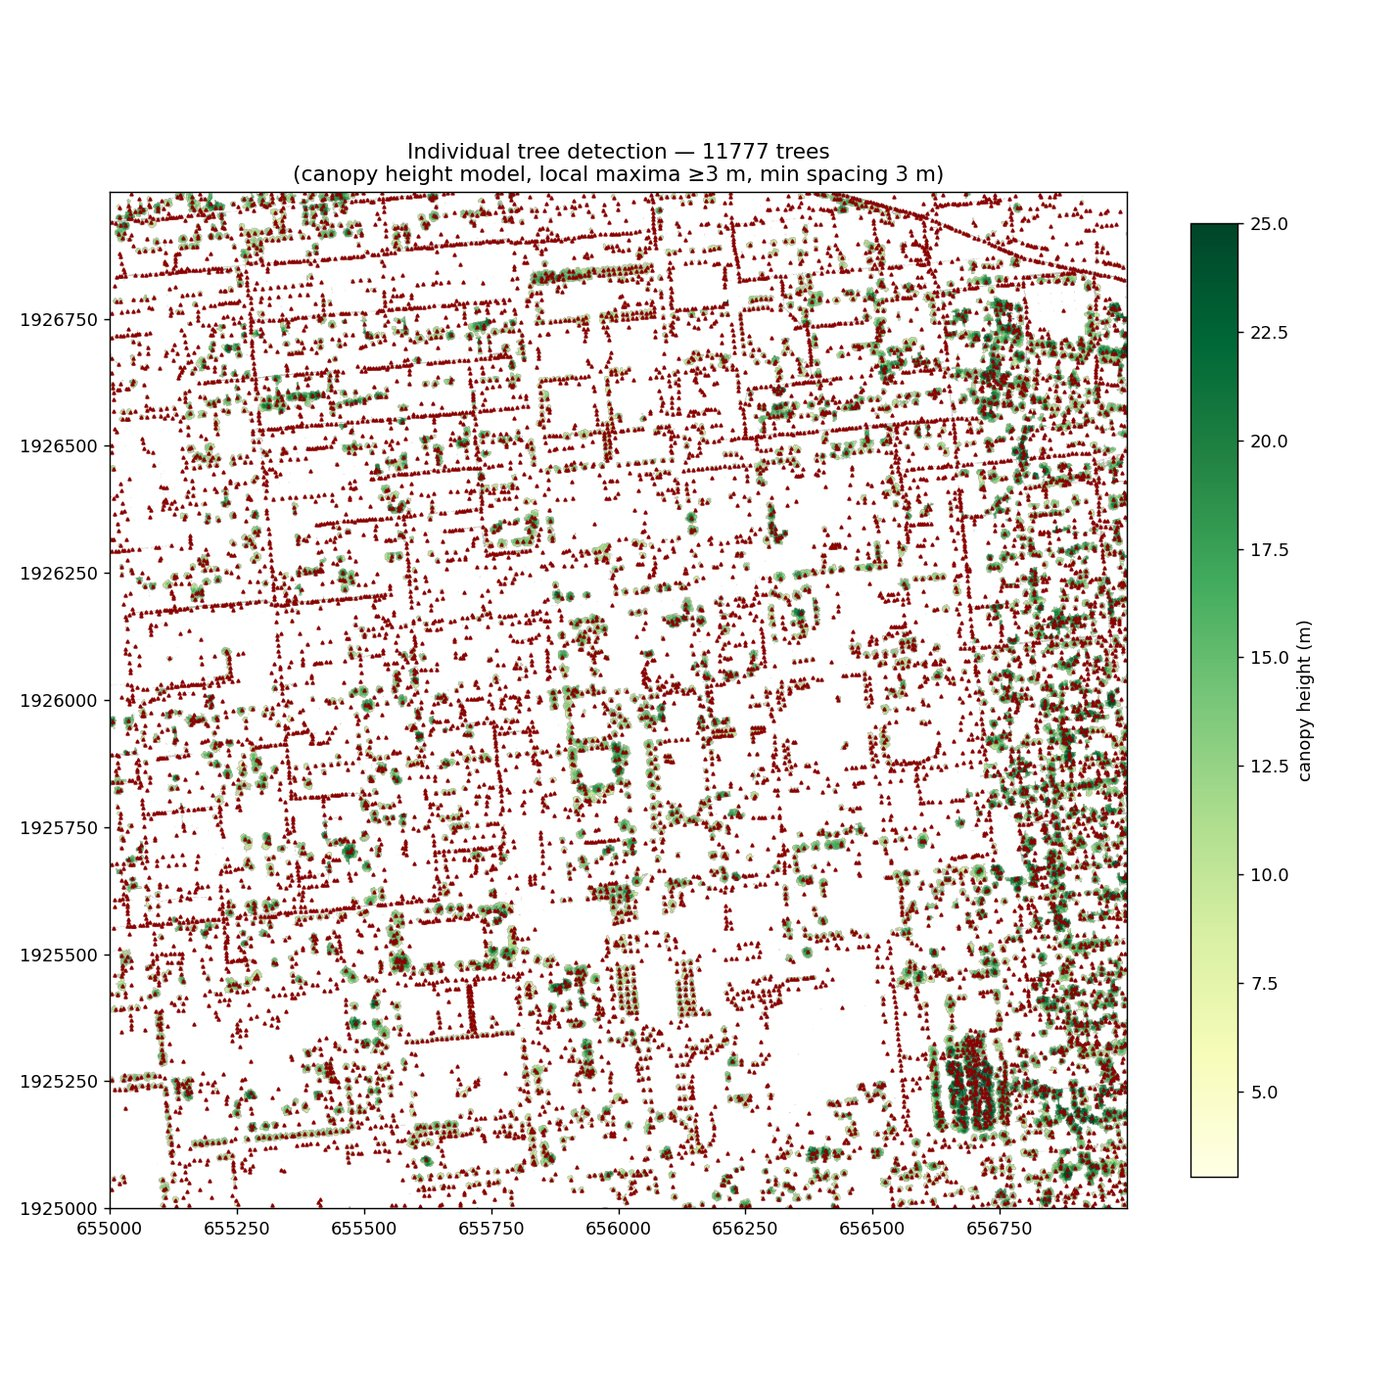

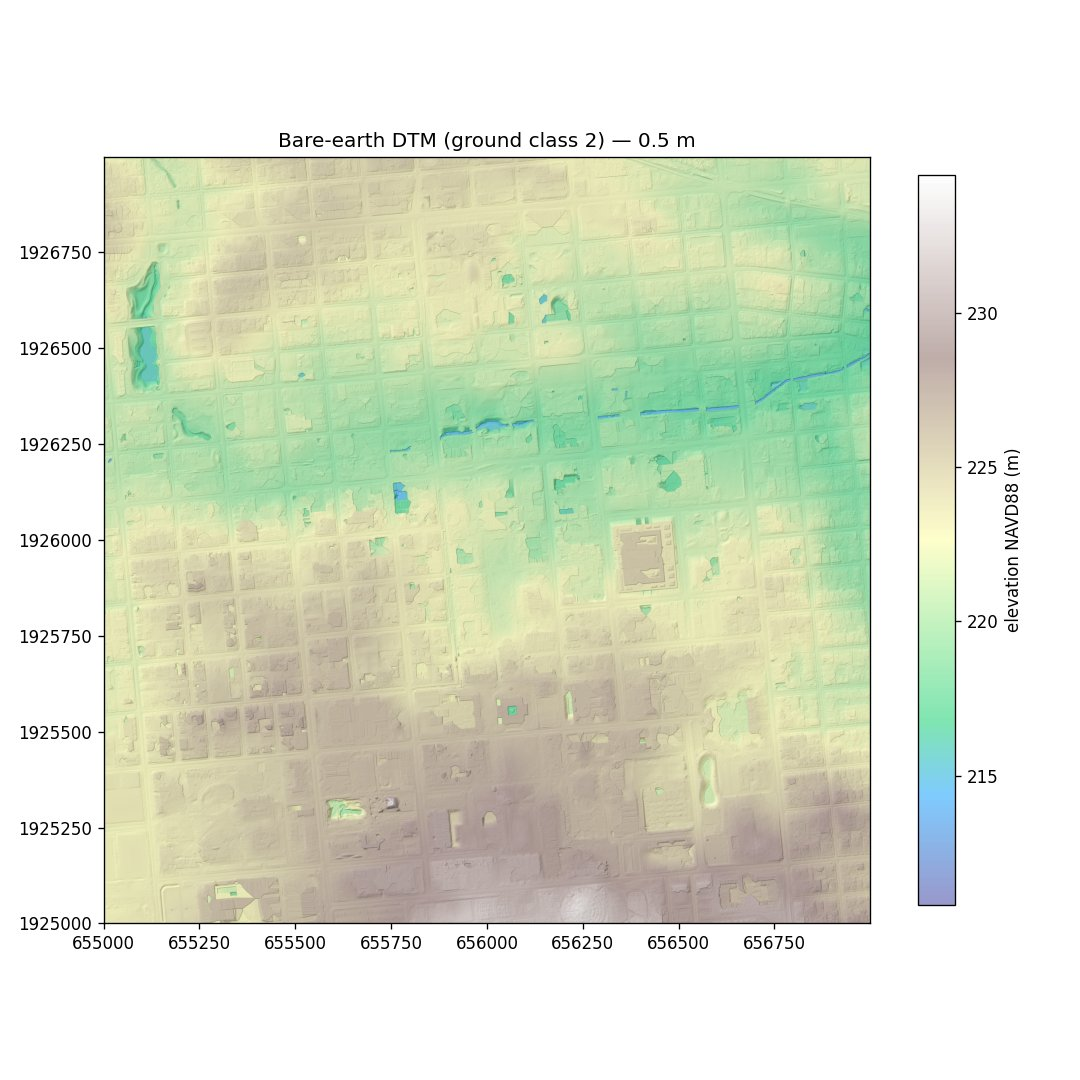

{
  "resolution_m": 0.5,
  "grid": [
    4000,
    4000
  ],
  "buildings": {
    "count": 1312,
    "total_footprint_m2": 943498.4,
    "median_height_m": 8.3,
    "tallest_m": 76.1
  },
  "trees": {
    "count": 11777,
    "median_height_m": 12.0,
    "tallest_m": 52.9,
    "median_crown_m2": 21.5
  }
}


In [5]:
show("results/uiuc_campus/detection/buildings_detected.png",
     "results/uiuc_campus/detection/trees_detected.png",
     "results/uiuc_campus/detection/ground_dtm.png")
jshow("results/uiuc_campus/detection/detection_summary.json")

## 4 · Stage 2 — Deep-learning semantic segmentation *(optional)*

`src/dgcnn_semseg.py` trains a **DGCNN (EdgeConv)** point-cloud segmentation model on
the ASPRS labels with a strict **spatial split** (west half = train, east half =
validation — random splits would leak neighboring points and inflate the score). The
key engineered feature is height-above-ground from Stage 1's DTM.

This stage demonstrates the *scalable-AI* direction of research question 3: a trained
model can label wall-to-wall tiles where no classified LiDAR exists. It is **not**
required for the bias analysis below (the classical footprints serve as ground truth),
so it is off by default — set `RUN_DL = True` in the configuration cell to train
(≈ 10–15 min on GPU/Apple-MPS; a CPU-only run can take 1–2 h).

Reference scores from the committed run: PointNet baseline OA 0.913 / mIoU 0.707 →
**DGCNN OA 0.930 / mIoU 0.768**.

RUN_DL = False -> skipping training; showing the committed reference figures


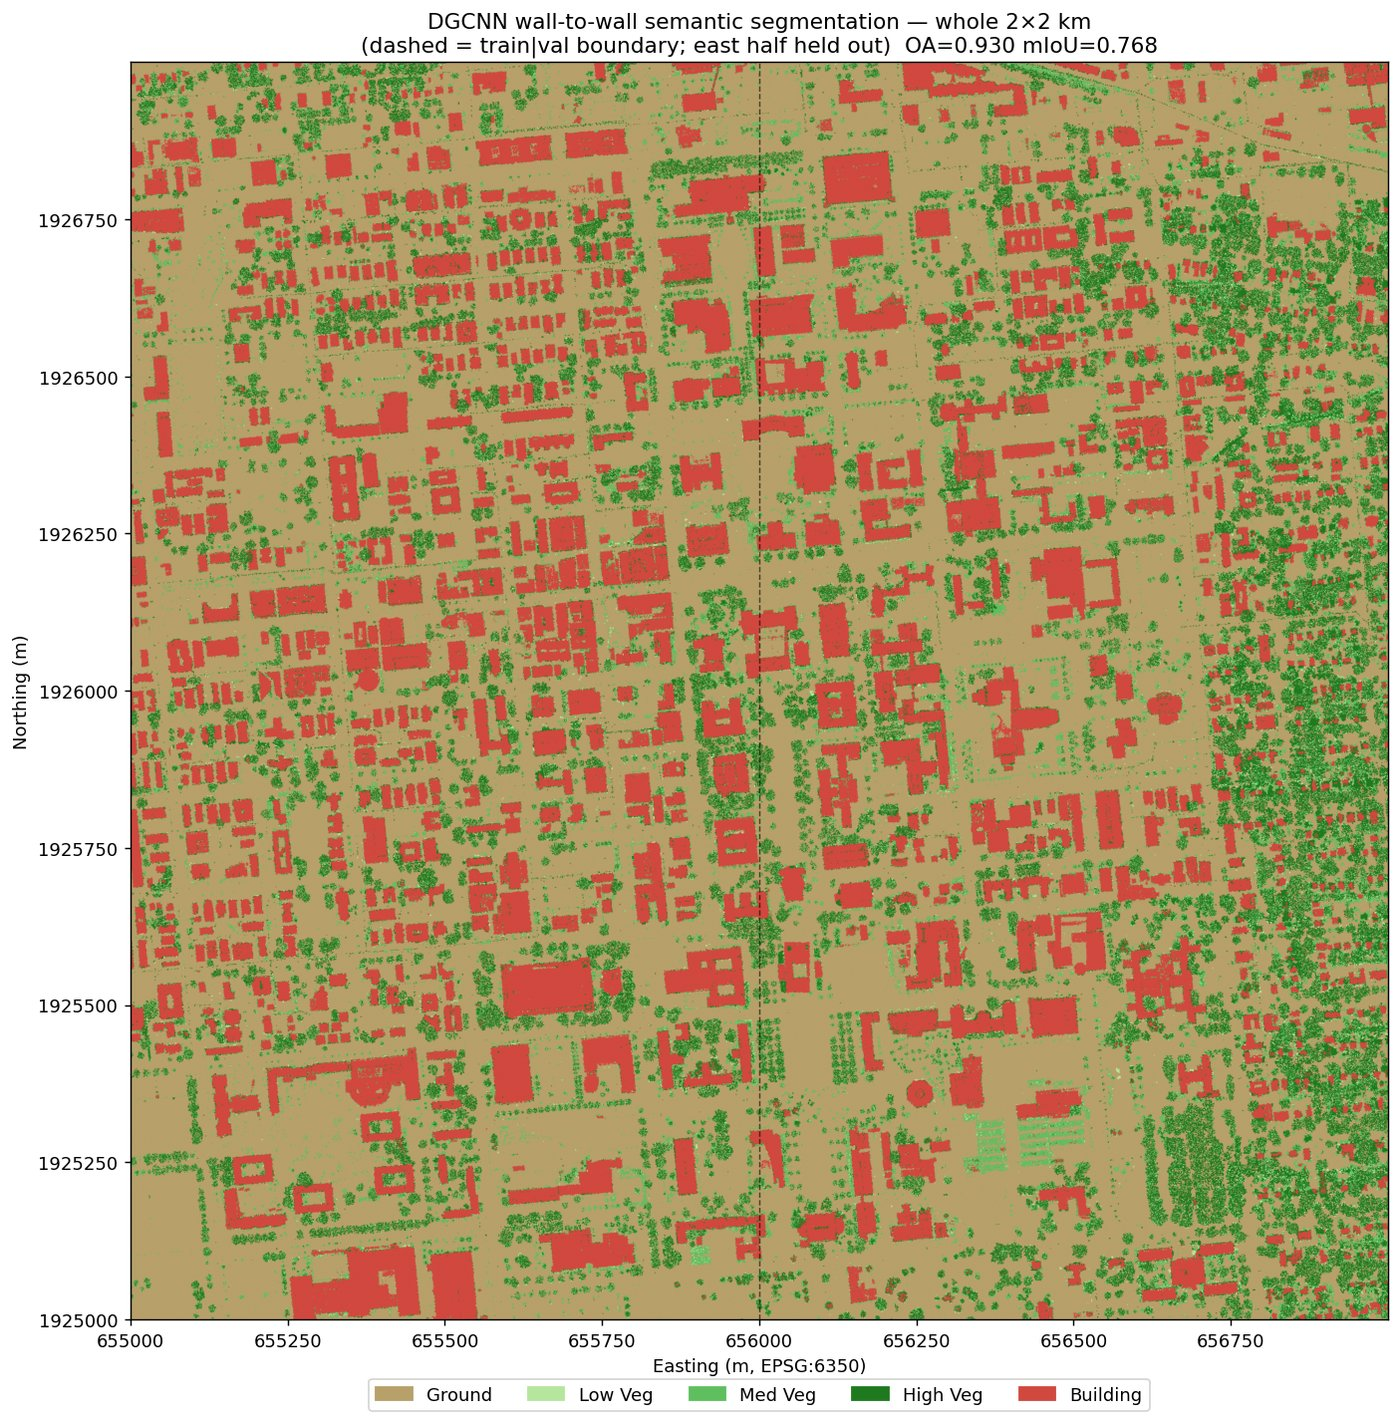

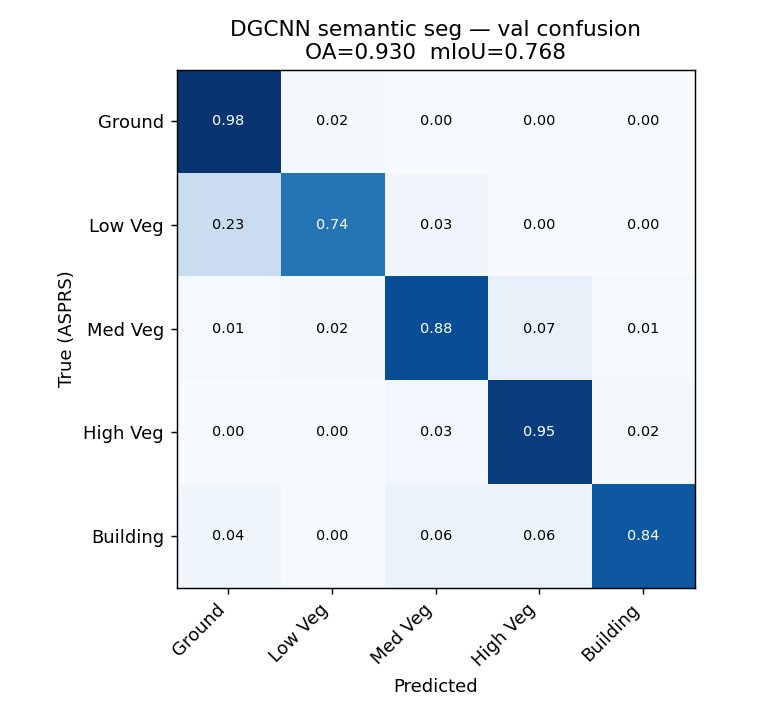

{
  "model": "DGCNN",
  "params_M": 0.332,
  "device": "mps",
  "overall_accuracy": 0.9297,
  "mean_IoU": 0.7677,
  "per_class_IoU": {
    "Ground": 0.9502,
    "Low Veg": 0.4906,
    "Med Veg": 0.7021,
    "High Veg": 0.8779,
    "Building": 0.8176
  },
  "baseline_pointnet": {
    "overall_accuracy": 0.9133,
    "mean_IoU": 0.7074
  }
}


In [6]:
RUN_DL = globals().get("RUN_DL", False)   # False if the config cell was not (re-)run
if RUN_DL:
    run("src/dgcnn_semseg.py")
else:
    print("RUN_DL = False -> skipping training; showing the committed reference figures")
show("results/uiuc_campus/segmentation/seg_fulltile.png", "results/uiuc_campus/segmentation/seg_confusion.png")
jshow("results/uiuc_campus/segmentation/seg_metrics.json")

## 5 · Stage 3 — NAIP optical segmentation (the corroborating sensor)

`src/naip_segmentation.py` derives land cover from the 4-band NAIP image:

- **Vegetation** — NDVI (NIR-based) OR excess-green index; robust and NAIP-only.
- **Impervious** — valid, non-vegetation, non-water pixels: the built-up extent.

Optical imagery has **no height information**, so buildings and pavement are
spectrally near-identical in a dense scene and cannot be separated by NAIP alone. The
resolution: intersect NAIP impervious with the LiDAR footprints —
`building = impervious ∩ LiDAR footprint`, and the remainder,
`paved = impervious − buildings`, becomes the road/parking reference used by Stage 5
(LiDAR has no road class, so roads need an optical reference). Crucially, NAIP's
impervious extent is **not trained on LiDAR** — the two sensors stay independent, which
is what makes their consensus meaningful.

In [7]:
run("src/naip_segmentation.py", "data/uiuc_campus/NAIP_image.tif")

$ python src/naip_segmentation.py data/uiuc_campus/NAIP_image.tif


/Users/yifn/Downloads/uiuc_campus_lidar/src/naip_segmentation.py:61: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  imperv = remove_small_objects(remove_small_holes(imperv, 60), 40)
/Users/yifn/Downloads/uiuc_campus_lidar/src/naip_segmentation.py:61: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  imperv = remov

/Users/yifn/Downloads/uiuc_campus_lidar/src/naip_segmentation.py:69: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  paved = remove_small_objects(paved, 60)


NAIP tile 2741x2968 px @ 0.73 m, EPSG:6350
{
  "resolution_m": 0.73,
  "vegetation_pct": 17.3,
  "impervious_pct": 83.9,
  "building_m2": 920934,
  "paved_m2": 2190913,
  "vegetation_m2": 693751,
  "note": "building = NAIP impervious \u2229 LiDAR footprint; paved = roads+parking+sidewalks"
}
done -> /Users/yifn/Downloads/uiuc_campus_lidar/results/uiuc_campus/naip


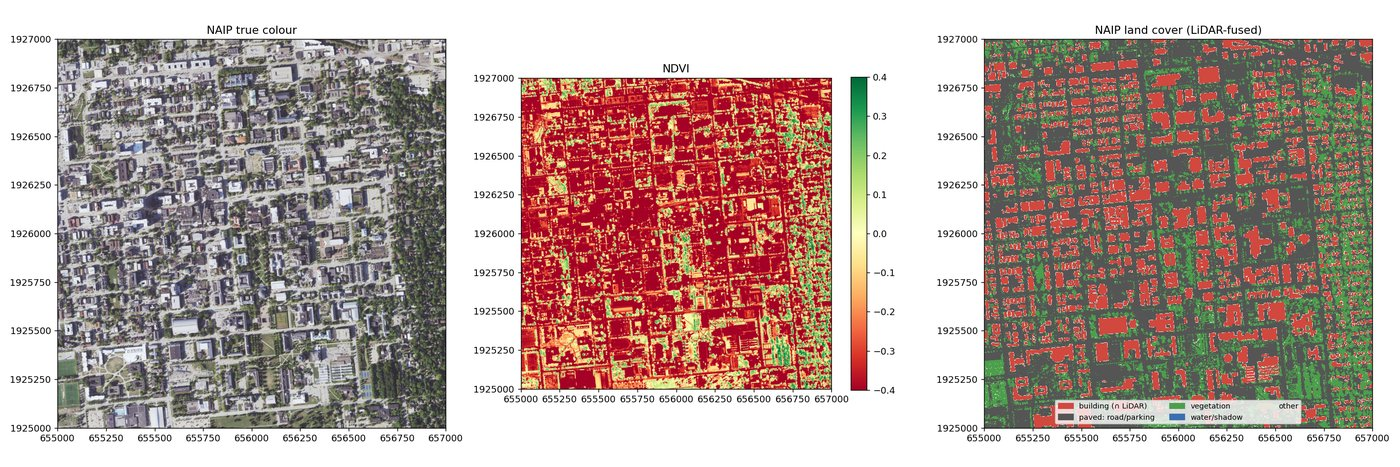

{
  "resolution_m": 0.73,
  "vegetation_pct": 17.3,
  "impervious_pct": 83.9,
  "building_m2": 920934,
  "paved_m2": 2190913,
  "vegetation_m2": 693751,
  "note": "building = NAIP impervious \u2229 LiDAR footprint; paved = roads+parking+sidewalks"
}


In [8]:
show("results/uiuc_campus/naip/naip_segmentation.png")
jshow("results/uiuc_campus/naip/naip_summary.json")

## 6 · Stage 4 — Buildings: OSM 2019 vs the RS consensus

`src/vgi_comparison.py` evaluates the temporally-matched OSM 2019 `building=*` polygons
against the LiDAR footprints (corroborated by NAIP):

- **Matching** — IoU ≥ 0.3 between OSM and LiDAR footprints (EPSG:6350 metres),
  tracking 1:1 and 1:N cases.
- **Completeness** — matched / all LiDAR buildings, by count and by area. The two
  diverge when OSM maps the big buildings but skips the small ones.
- **Commission** — OSM polygons with no LiDAR support (stale, mislocated, or
  sub-threshold structures; interpreted per case, not automatically "wrong").
- **Gridded bias map** — completeness per 100 m cell: the *spatial* signature of bias.

`src/pixel_comparison.py` repeats the test at the pixel level (0.2 m), giving overall
accuracy, building-pixel IoU and Cohen's κ — a rasterized view that is insensitive to
how buildings are split into polygons.

In [9]:
run("src/vgi_comparison.py", "data/uiuc_campus/osm_buildings_2019.geojson")
run("src/pixel_comparison.py", "data/uiuc_campus/osm_buildings_2019.geojson")

$ python src/vgi_comparison.py data/uiuc_campus/osm_buildings_2019.geojson


/Users/yifn/Downloads/uiuc_campus_lidar/src/vgi_comparison.py:99: RuntimeWarning: invalid value encountered in divide
  comp = np.where(tot > 0, mat/tot, np.nan)


LiDAR buildings: 1312   reference: 1121
{
  "reference": "osm_buildings_2019.geojson",
  "iou_threshold": 0.3,
  "lidar_buildings": 1312,
  "reference_buildings": 1121,
  "matched": 765,
  "completeness_count": 0.5831,
  "completeness_area": 0.7941,
  "reference_commission": 0.2953,
  "lidar_only_omissions": 547,
  "reference_only": 331,
  "median_matched_iou": 0.783
}
done -> /Users/yifn/Downloads/uiuc_campus_lidar/results/uiuc_campus/comparison
$ python src/pixel_comparison.py data/uiuc_campus/osm_buildings_2019.geojson


[0p2m] grid 10000 x 10000 = 100 M pixels
{
  "resolution_m": 0.2,
  "grid": [
    10000,
    10000
  ],
  "building_pixel_IoU": 0.6981,
  "pixel_agreement_OA": 0.9236,
  "cohen_kappa": 0.7741,
  "agree_building_m2": 706968.8,
  "lidar_only_m2": 234830.5,
  "reference_only_m2": 70931.2,
  "disagreement_m2": 305761.7
}
done -> /Users/yifn/Downloads/uiuc_campus_lidar/results/uiuc_campus/comparison/pixel


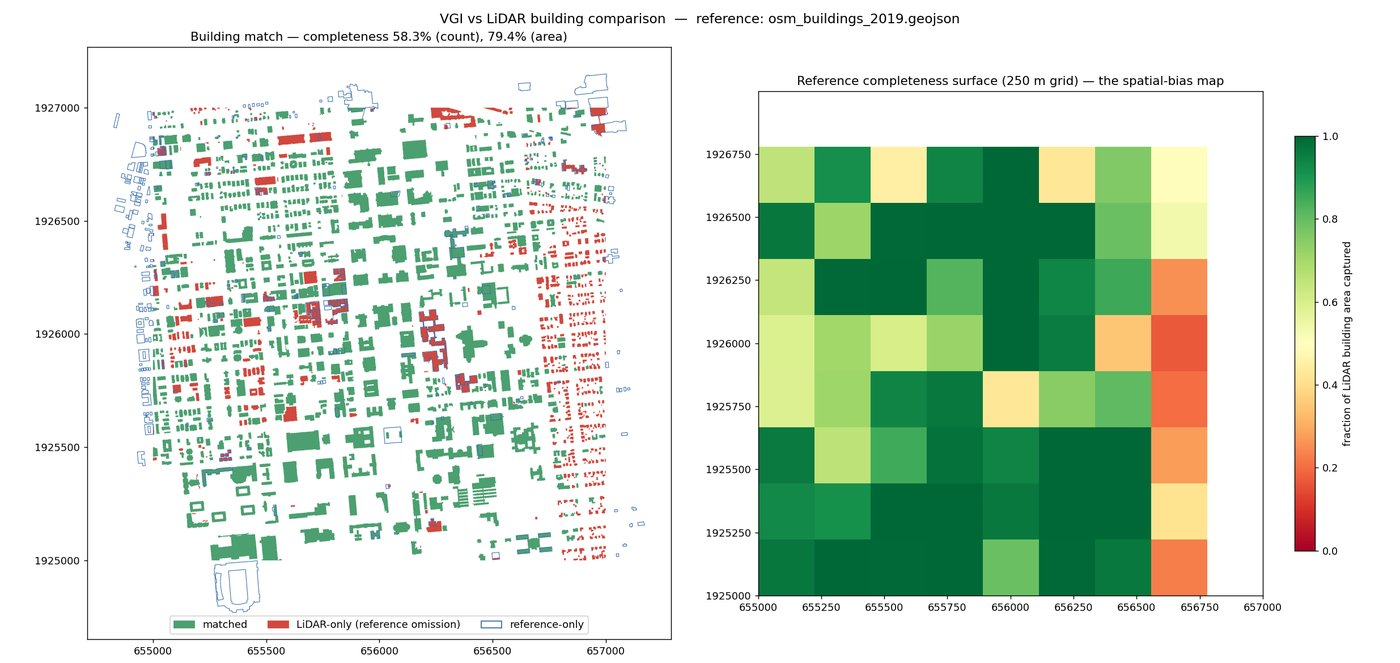

{
  "reference": "osm_buildings_2019.geojson",
  "iou_threshold": 0.3,
  "lidar_buildings": 1312,
  "reference_buildings": 1121,
  "matched": 765,
  "completeness_count": 0.5831,
  "completeness_area": 0.7941,
  "reference_commission": 0.2953,
  "lidar_only_omissions": 547,
  "reference_only": 331,
  "median_matched_iou": 0.783
}
{
  "resolution_m": 0.2,
  "grid": [
    10000,
    10000
  ],
  "building_pixel_IoU": 0.6981,
  "pixel_agreement_OA": 0.9236,
  "cohen_kappa": 0.7741,
  "agree_building_m2": 706968.8,
  "lidar_only_m2": 234830.5,
  "reference_only_m2": 70931.2,
  "disagreement_m2": 305761.7
}


In [10]:
show("results/uiuc_campus/comparison/comparison_map.png")
jshow("results/uiuc_campus/comparison/comparison_summary.json")
jshow("results/uiuc_campus/comparison/pixel/pixel_metrics_0p2m.json")

### Reading the result

OSM 2019 captures **58.3 % of buildings by count but 79.4 % by area** — the classic
VGI signature: large institutional buildings get mapped, small residential structures
(garages, sheds, back-lot houses) do not. The bias map shows completeness ≈ 1.0 on the
campus core collapsing **below 0.3 on the eastern residential strip** — a sharp spatial
gradient inside a single 2 × 2 km tile.

### Temporal validation — were the "omissions" real?

If the 2019 gaps were genuine unmapped buildings (not LiDAR artifacts or unbuilt lots),
the OSM community should have filled many of them since. Re-running the comparison
against the **OSM 2026** snapshot and diffing the two
(`src/temporal_validation.py`) classifies every 2019 gap as *filled by 2026* vs
*still unmapped*.

In [11]:
run("src/vgi_comparison.py", "data/uiuc_campus/osm_buildings_2026.geojson", "osm2026")
run("src/temporal_validation.py")

$ python src/vgi_comparison.py data/uiuc_campus/osm_buildings_2026.geojson osm2026


/Users/yifn/Downloads/uiuc_campus_lidar/src/vgi_comparison.py:99: RuntimeWarning: invalid value encountered in divide
  comp = np.where(tot > 0, mat/tot, np.nan)


LiDAR buildings: 1312   reference: 1657
{
  "reference": "osm_buildings_2026.geojson",
  "iou_threshold": 0.3,
  "lidar_buildings": 1312,
  "reference_buildings": 1657,
  "matched": 1074,
  "completeness_count": 0.8186,
  "completeness_area": 0.9181,
  "reference_commission": 0.3349,
  "lidar_only_omissions": 238,
  "reference_only": 555,
  "median_matched_iou": 0.765
}
done -> /Users/yifn/Downloads/uiuc_campus_lidar/results/uiuc_campus/comparison/osm2026
$ python src/temporal_validation.py


{
  "lidar_buildings": 1312,
  "osm2019_buildings": 1121,
  "osm2026_buildings": 1657,
  "mapped_2019": 765,
  "gaps_2019": 547,
  "filled_by_2026": 352,
  "still_unmapped": 195,
  "gap_fill_rate": 0.6435,
  "completeness_2019_count": 0.5831,
  "completeness_2026_count": 0.8186,
  "completeness_2019_area": 0.7941,
  "completeness_2026_area": 0.9181
}
done -> /Users/yifn/Downloads/uiuc_campus_lidar/results/uiuc_campus/comparison/temporal


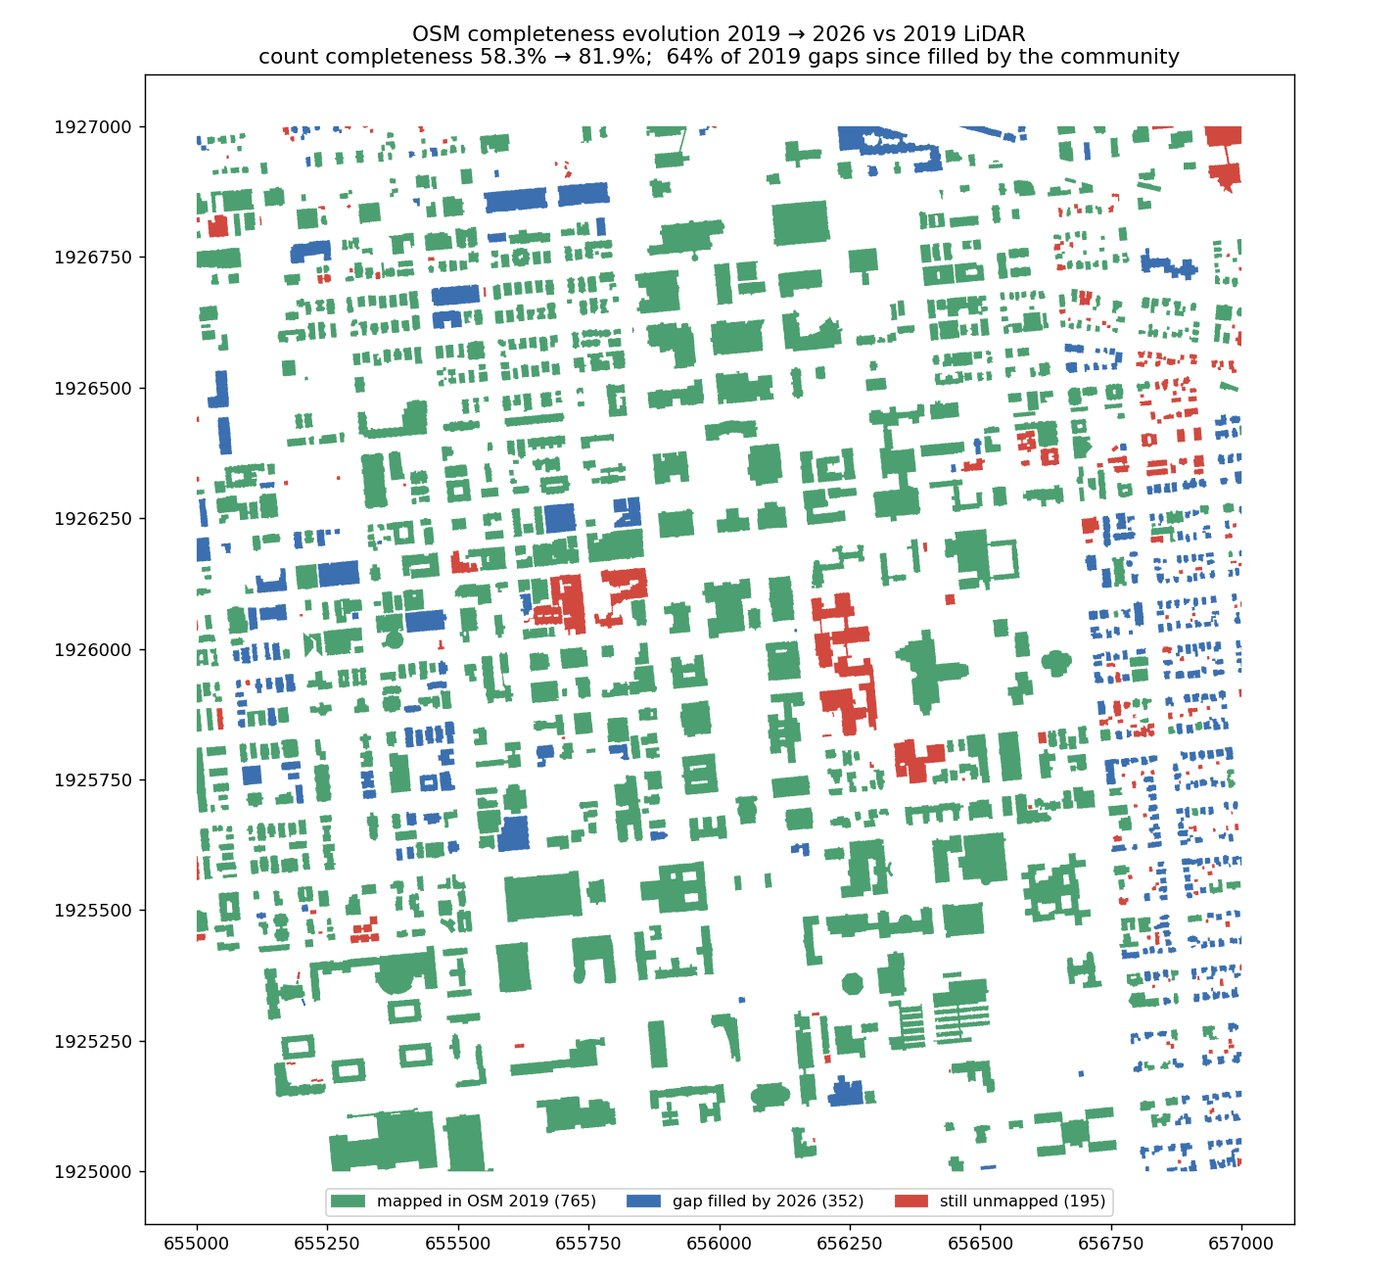

{
  "lidar_buildings": 1312,
  "osm2019_buildings": 1121,
  "osm2026_buildings": 1657,
  "mapped_2019": 765,
  "gaps_2019": 547,
  "filled_by_2026": 352,
  "still_unmapped": 195,
  "gap_fill_rate": 0.6435,
  "completeness_2019_count": 0.5831,
  "completeness_2026_count": 0.8186,
  "completeness_2019_area": 0.7941,
  "completeness_2026_area": 0.9181
}


In [12]:
show("results/uiuc_campus/comparison/temporal/temporal_evolution.png")
jshow("results/uiuc_campus/comparison/temporal/temporal_summary.json")

**64 % of the 2019 gaps (352/547) were filled by the community by 2026** — they were in
the 2019 LiDAR all along, so they were real omissions, not yet-unbuilt structures.
Completeness rises to 81.9 % / 91.8 % against the 2026 snapshot. This validates the RS
consensus as an *early-warning* signal: remote sensing saw in 2019 what volunteers took
seven years to map.

## 7 · Stage 5 — Roads: OSM vs the NAIP paved layer

LiDAR has no road class, so the reference for roads is Stage 3's **paved layer**
(impervious − buildings). `src/road_comparison.py` tests both directions:

- **Forward (RS support)** — buffer each OSM way by a class-dependent width (+1.5 m
  positional tolerance) and measure the fraction of the buffer that is NAIP-paved.
  Support ≥ 0.5 ⇒ the way has physical pavement evidence.
- **Reverse (explained pavement)** — the fraction of paved pixels covered by any
  buffered OSM way. The remainder is *candidate* unmapped ways — but paved is a
  superset of roads (parking lots, plazas), so unexplained ≠ automatically missing.

Two follow-ups sharpen the picture:

- `src/road_evolution.py` classifies every way **added between 2019 and 2026** by
  whether it was already paved in the 2019 imagery — separating *gap-fill* (existed,
  unmapped) from *new construction*.
- `src/major_roads_analysis.py` runs the identical test on the vetted **major-roads
  subset** (`data/uiuc_campus/osm_roads_2019_major.geojson`, the campus clip of the statewide
  extract used in Stage 6) — the bridge between the two scales of this study.

Known caveats (documented in `results/uiuc_campus/comparison/README.md`): tree canopy shadows
optical pavement on residential streets (false "unsupported"), and legitimately unpaved
tracks/paths have no pavement to find.

In [13]:
run("src/road_comparison.py")
run("src/road_evolution.py")
run("src/major_roads_analysis.py")

$ python src/road_comparison.py


{
  "2019": {
    "snapshot": "2019",
    "segments": 3383,
    "length_km": 246.29,
    "support_threshold": 0.5,
    "supported_segments": 0.8463,
    "supported_length": 0.9107,
    "median_support": 0.833,
    "paved_explained": 0.5492
  },
  "2026": {
    "snapshot": "2026",
    "segments": 5402,
    "length_km": 266.67,
    "support_threshold": 0.5,
    "supported_segments": 0.8671,
    "supported_length": 0.9077,
    "median_support": 0.888,
    "paved_explained": 0.5856
  }
}
done -> /Users/yifn/Downloads/uiuc_campus_lidar/results/uiuc_campus/comparison/roads
$ python src/road_evolution.py


{
  "ways_2019": 3383,
  "ways_2026": 5402,
  "km_2019": 246.29,
  "km_2026": 266.67,
  "existed_2019": 4962,
  "km_existed": 246.05,
  "added_by_2026": 440,
  "km_added": 20.62,
  "added_paved_in_2019": 329,
  "km_added_paved": 16.47,
  "added_no_2019_evidence": 111,
  "km_added_no_evidence": 4.15,
  "gap_fill_share_of_added_km": 0.7987,
  "ways_2019_gone_by_2026": 116,
  "km_gone": 4.82,
  "match_tolerance_m": 5.0,
  "support_threshold": 0.5
}
done -> /Users/yifn/Downloads/uiuc_campus_lidar/results/uiuc_campus/comparison/temporal
$ python src/major_roads_analysis.py


{
  "snapshot": "2019_major",
  "segments": 154,
  "length_km": 46.64,
  "support_threshold": 0.5,
  "supported_segments": 0.9935,
  "supported_length": 0.9955,
  "median_support": 0.935,
  "paved_explained": 0.2056,
  "attributes": {
    "pct_maxspeed": 26.0,
    "pct_surface": 37.7,
    "pct_name": 97.4
  },
  "attributes_statewide_county_mean": {
    "pct_maxspeed": 1.44,
    "pct_surface": 1.72,
    "pct_name": 73.9
  },
  "median_edit_year": 2018,
  "pct_edited_2017plus": 94.2
}
by_class: {
 "residential": {
  "n": 104,
  "km": 30.07,
  "supported": 0.99
 },
 "tertiary": {
  "n": 44,
  "km": 12.56,
  "supported": 1.0
 }
}


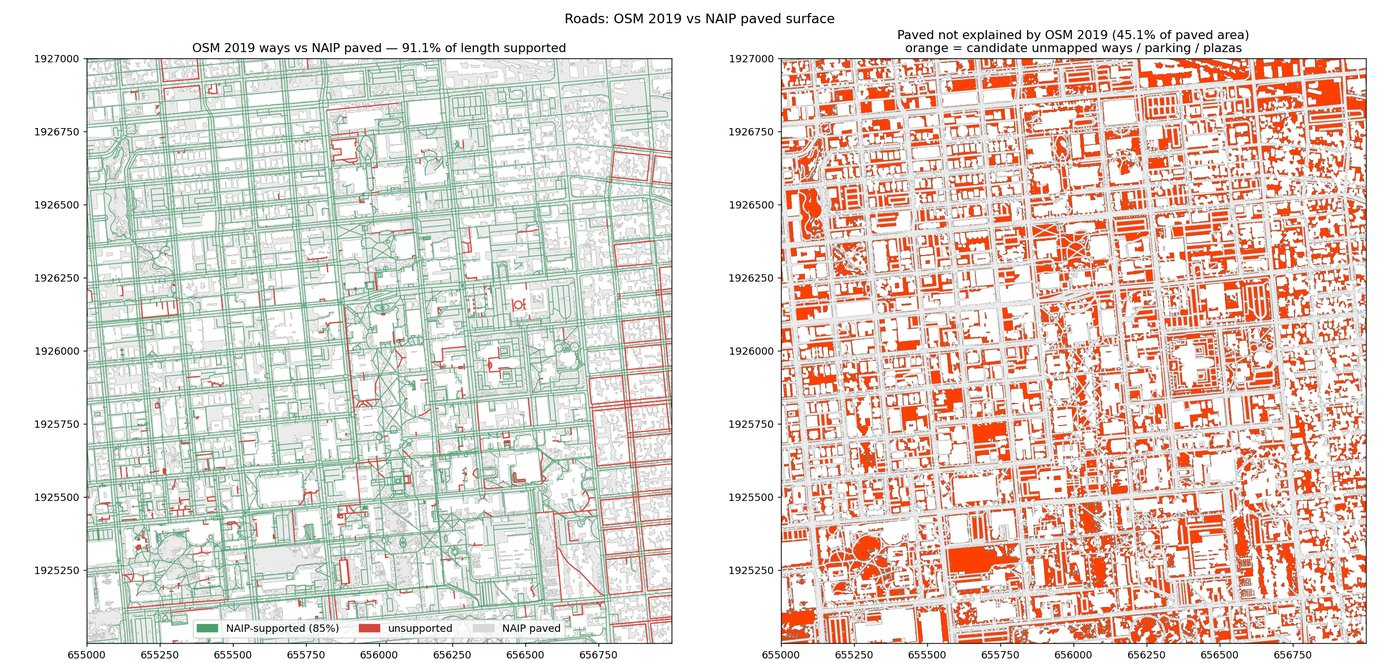

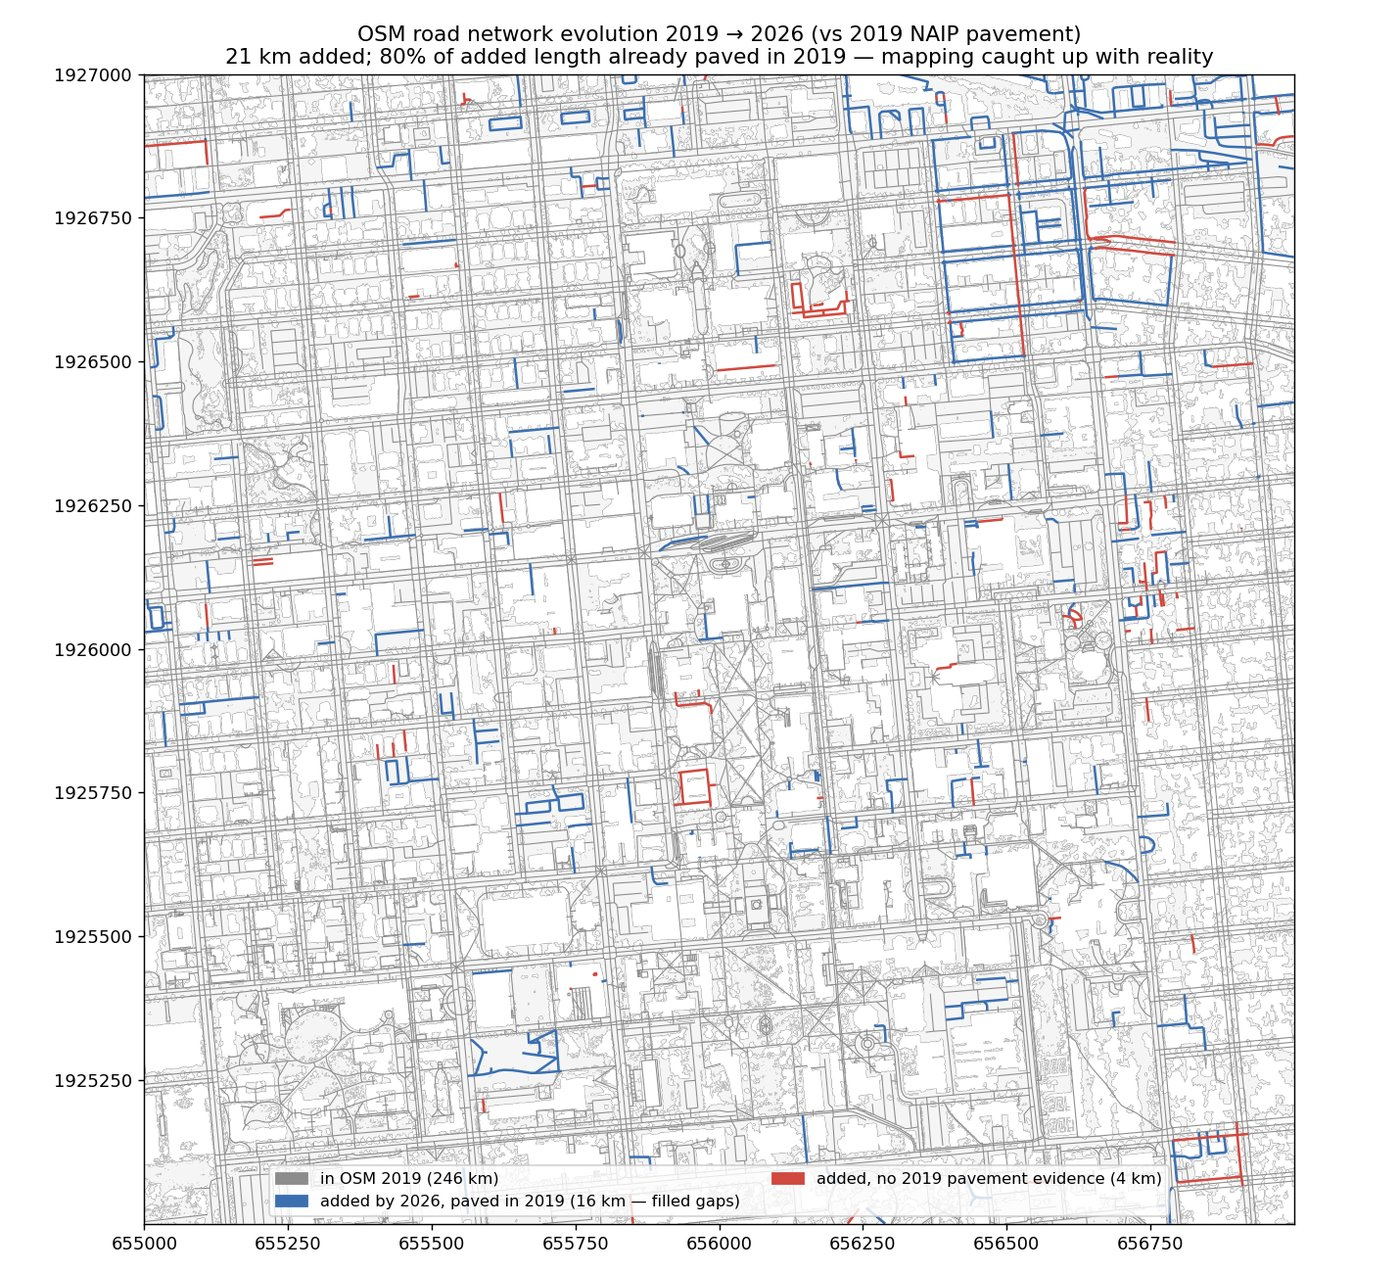

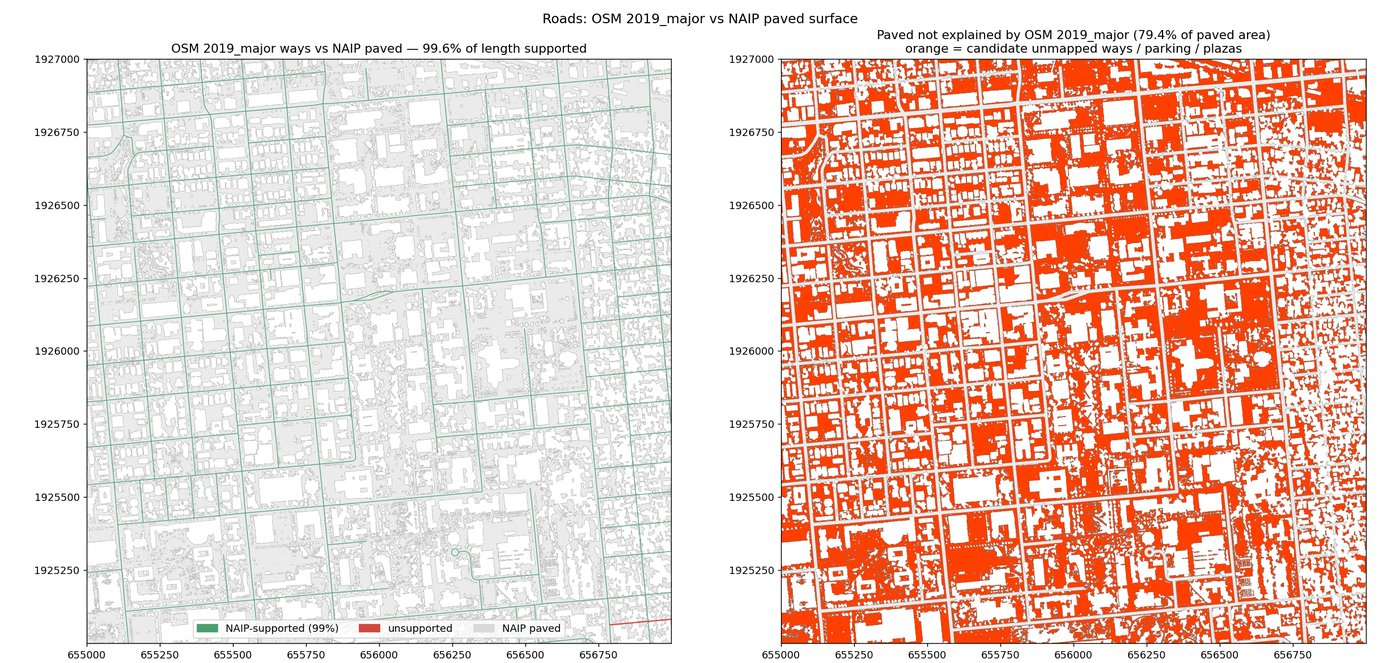

{
  "snapshot": "2019_major",
  "segments": 154,
  "length_km": 46.64,
  "support_threshold": 0.5,
  "supported_segments": 0.9935,
  "supported_length": 0.9955,
  "median_support": 0.935,
  "paved_explained": 0.2056,
  "attributes": {
    "pct_maxspeed": 26.0,
    "pct_surface": 37.7,
    "pct_name": 97.4
  },
  "attributes_statewide_county_mean": {
    "pct_maxspeed": 1.44,
    "pct_surface": 1.72,
    "pct_name": 73.9
  },
  "median_edit_year": 2018,
  "pct_edited_2017plus": 94.2
}


In [14]:
show("results/uiuc_campus/comparison/roads/roads_2019.png",
     "results/uiuc_campus/comparison/temporal/roads_evolution.png",
     "results/uiuc_campus/comparison/roads/roads_2019_major.png")
jshow("results/uiuc_campus/comparison/roads/major_roads_summary.json", drop=("by_class",))

**Roads were already well-mapped in 2019 where buildings were not** — 91 % of way
length has pavement support, and the vetted major-roads subset is **99.6 % supported**
(the all-class shortfall is almost entirely canopy-shaded footways/steps). The
2019→2026 additions are dominated by micro-mapping (+60 % segments but only +8 %
length), and **80 % of the added length was already paved in 2019** — gap-fill again,
mirroring the buildings story. The major-roads clip also shows the attribute contrast
that motivates Stage 6: on campus, 26 % of ways carry a `maxspeed` and 94 % were edited
2017+, an order of magnitude above the statewide average.

## 8 · Stage 6 — Statewide scaling: the urban→rural bias gradient

The campus tile is one (extremely well-mapped) point in a much larger quality
landscape. `src/statewide_bias.py` scales the analysis to **375,754 major-road segments
(235,064 km) across all 102 Illinois counties**, asking research question 1 directly:
*does OSM quality vary systematically with who lives there?*

Per county it computes three families of metrics, then tests each against population
density (Spearman rank correlation — no linearity assumption) and contrasts urban
(≥ 100 persons/km²) vs rural counties:

- **Attribute completeness** — % of segments tagged with `maxspeed`, `surface`, `ref`,
  a street name. Geometry can exist while attributes are missing; attribute effort is a
  direct proxy for contributor attention.
- **Edit recency** — median `lastchange` year and % of segments touched 2017+. A road
  drawn once by a 2008 bulk import and never revisited is *unverified*, whatever its
  geometric quality.
- **Supply** — road-length density (km/km²) and km per 1,000 residents, normalized with
  Census 2019 land area and population estimates.

In [15]:
run("src/statewide_bias.py",
    "data/statewide_il/OSM_2019_Major_Roads/gis_osm_roads_2019_IL_Major_Roads.shp",
    "data/statewide_il", "results/statewide_il")

$ python src/statewide_bias.py data/statewide_il/OSM_2019_Major_Roads/gis_osm_roads_2019_IL_Major_Roads.shp data/statewide_il results/statewide_il


          metric  spearman_rho  p_value  urban_mean  rural_mean
    pct_maxspeed        0.5021   0.0000      3.1045      1.2166
     pct_surface        0.5980   0.0000      2.4543      1.6195
         pct_ref        0.2363   0.0168      5.6674      4.1261
        pct_name        0.6517   0.0000     92.3449     71.4518
      pct_recent        0.6967   0.0000     29.9298      9.2903
median_edit_year        0.5874   0.0000   2014.1667   2012.3111
    road_density        0.7065   0.0000      3.5985      1.3114
       km_per_1k       -0.9710   0.0000     11.6432     85.5889

Saved: results/statewide_il/county_metrics.csv, bias_tests.csv, 2 figures


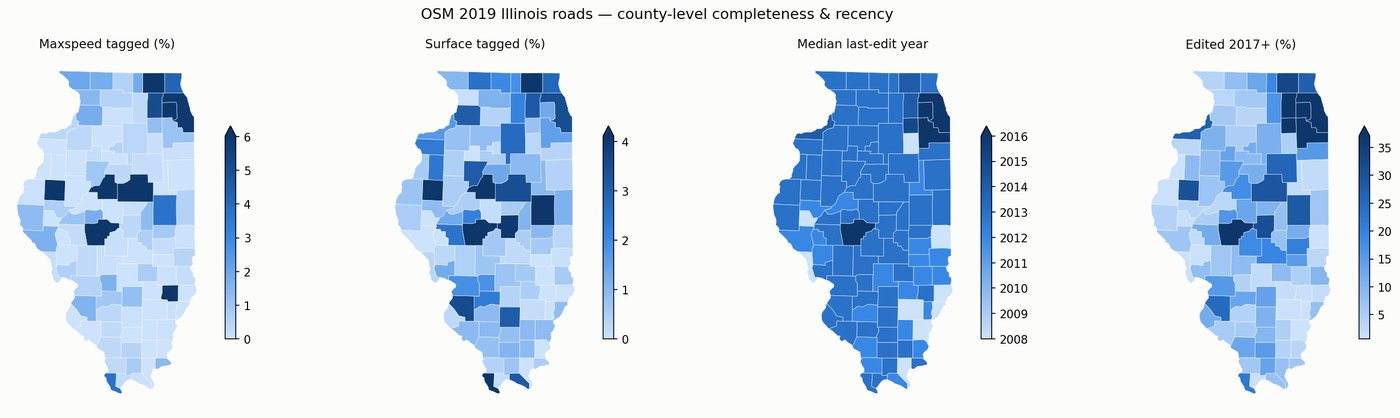

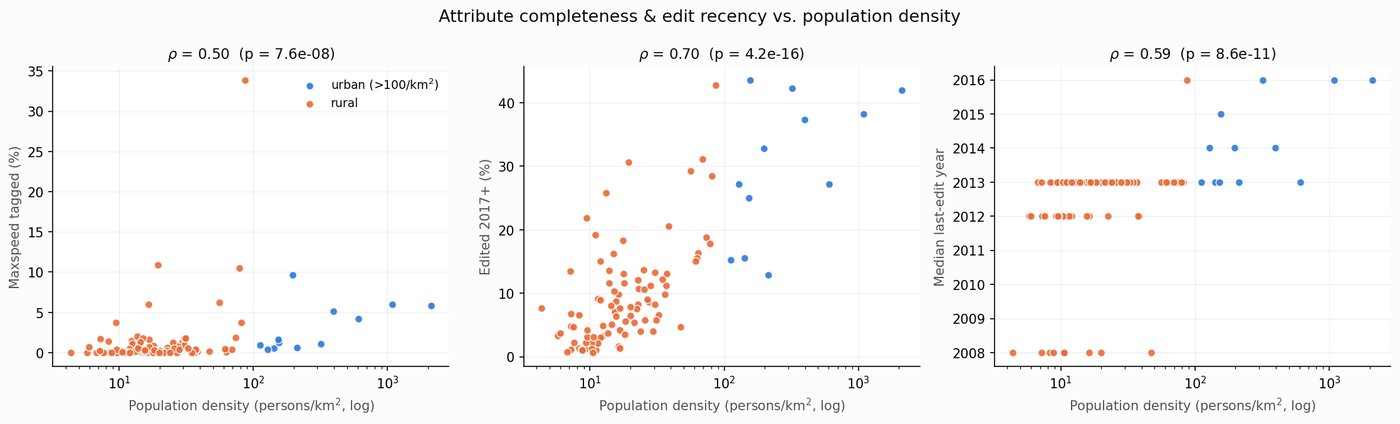

,metric,spearman_rho,p_value,urban_mean,rural_mean
0,pct_maxspeed,0.502,0.000,3.104,1.217
1,pct_surface,0.598,0.000,2.454,1.619
2,pct_ref,0.236,0.017,5.667,4.126
3,pct_name,0.652,0.000,92.345,71.452
4,pct_recent,0.697,0.000,29.930,9.290
5,median_edit_year,0.587,0.000,2014.167,2012.311
6,road_density,0.706,0.000,3.598,1.311
7,km_per_1k,-0.971,0.000,11.643,85.589


In [16]:
import pandas as pd
show("results/statewide_il/choropleth_completeness.png",
     "results/statewide_il/scatter_bias.png", width=1100)
pd.read_csv(os.path.join(REPO, "results/statewide_il/bias_tests.csv")).round(3)

### Reading the gradient

All correlations are significant at p < 0.001:

1. **Attribute completeness and recency are strongly urban-biased** (recency ρ = 0.70,
   maxspeed ρ = 0.50). Several downstate counties have a median last-edit year of
   **2008** — untouched since the original TIGER import — while Cook/DuPage/Will sit at
   2016 and the campus tile at 2018.
2. **Geometric supply is near-complete everywhere**: km per 1,000 residents is *higher*
   in rural counties (ρ = −0.97, an artifact of low population, not better mapping). In
   the US, the TIGER import means **bias lives in attributes and currency, not in
   whether the line exists** — which is exactly what the campus pilot found at object
   level.
3. **The gradient is not smooth.** Sangamon County (Springfield) tags `maxspeed` on
   33.9 % of segments — 3–10× any other county — the signature of a single dedicated
   contributor. Community attention, not just population, drives quality.

## 9 · Stage 7 — From detection to correction

Detection tells us *what is missing*; this stage proposes *the fix* — and, because
the community filled 352 of our 547 detected gaps by 2026, we can score every
proposal against **what mappers actually drew**, with no manual labeling. Three
approaches are compared (the correction ablation):

| | Geometry | Confidence |
|---|---|---|
| **A** | rule regularization (min-rotated-rect / orthogonalized ring) | rule tiers: area ≥ 80 m² + height ≥ 4 m + NAIP-impervious ≥ 0.5 |
| **B** | U-Net on NAIP RGBN + CHM, trained on the west-half community polygons | mean mask probability |
| **C** | same as A | gradient-boosted "acceptance scorer" (6 features) |

All learning uses the same west-train / east-eval spatial split as Stage 2, so
nothing is evaluated where it trained. Proposals carry OSM-ready tags
(`building=yes`, `height=*` from LiDAR) but remain **research artifacts** — per the
OSM Automated Edits Code of Conduct they are inputs for human review
(e.g. a MapRoulette challenge), never a bot upload.

Finally, the statewide metrics from Stage 6 are combined into a deployment-priority
map: `staleness × population exposure` says *where* this pipeline should be pointed
first. `RUN_LEARNED = False` skips the U-Net training and reuses the committed
proposals.

In [17]:
RUN_LEARNED = globals().get("RUN_LEARNED", False)   # False if the config cell was not (re-)run
run("src/propose_geometry.py")
run("src/acceptance_scorer.py")
if RUN_LEARNED:
    run("src/propose_learned.py")
else:
    print("RUN_LEARNED = False -> using the committed learned proposals")
run("src/correction_benchmark.py")
run("src/deploy_priority.py")

$ python src/propose_geometry.py


{
  "gaps": 547,
  "filled": 352,
  "still_unmapped": 195,
  "regularized": 536,
  "hull_fallbacks": 11,
  "east_eval_filled": 269
}
$ python src/acceptance_scorer.py


/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/shapely/constructive.py:1353: RuntimeWarning: invalid value encountered in oriented_envelope
  return lib.oriented_envelope(geometry, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/shapely/constructive.py:1353: RuntimeWarning: divide by zero encountered in oriented_envelope
  return lib.oriented_envelope(geometry, **kwargs)


{
  "train_gaps": 130,
  "train_filled": 83,
  "eval_gaps": 417,
  "eval_filled": 269,
  "auc_rule_tiers": 0.742,
  "auc_gbm": 0.738,
  "precision_at_50_rule": 0.62,
  "precision_at_50_gbm": 0.84,
  "base_rate_eval": 0.645,
  "gbm_feature_importance": {
    "area_m2": 0.671,
    "height_m": 0.088,
    "imperv_frac": 0.022,
    "dist_road": 0.075,
    "neigh_completeness": 0.042,
    "fill_ratio": 0.101
  }
}
$ python src/propose_learned.py


/Users/yifn/Downloads/uiuc_campus_lidar/src/propose_learned.py:135: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  tot += float(loss) * len(b)


device=mps  train patches=664 (from 83 west gaps)
epoch 10/40  bce=0.1624
epoch 20/40  bce=0.1344
epoch 30/40  bce=0.1057
epoch 40/40  bce=0.0937
{
  "device": "mps",
  "epochs": 40,
  "train_patches": 664,
  "train_gaps": 83,
  "east_pixel_iou_median": 0.468,
  "fallbacks": 106
}


$ python src/correction_benchmark.py


{
  "geometry_east_filled": {
    "rule (A/C)": {
      "n": 269,
      "median_iou": 0.677,
      "mean_iou": 0.642,
      "median_centroid_off_m": 1.45,
      "median_area_ratio": 1.15
    },
    "learned (B)": {
      "n": 269,
      "median_iou": 0.532,
      "mean_iou": 0.497,
      "median_centroid_off_m": 1.67,
      "median_area_ratio": 0.7
    },
    "raw LiDAR": {
      "n": 269,
      "median_iou": 0.691,
      "mean_iou": 0.665,
      "median_centroid_off_m": 1.39,
      "median_area_ratio": 1.04
    }
  },
  "confidence_east": {
    "auc": {
      "rule_tiers": 0.742,
      "gbm": 0.738,
      "unet_mask": 0.687
    },
    "precision_at_50": {
      "rule_tiers": 0.62,
      "gbm": 0.84,
      "unet_mask": 0.68
    },
    "base_rate": 0.645,
    "eval_gaps": 417
  }
}
figures -> /Users/yifn/Downloads/uiuc_campus_lidar/results/uiuc_campus/correction
$ python src/deploy_priority.py


         CTYNAME  POPESTIMATE2019  pct_recent  priority
     Cook County          5150233   41.988871    0.5801
     Lake County           696535   27.198013    0.5259
Winnebago County           282572   12.886744    0.5202
  Madison County           262966   15.549966    0.4959
   DuPage County           922921   38.237360    0.4703
   Peoria County           179179   15.219885    0.4527
St. Clair County           259686   24.967838    0.4393
     Kane County           532403   37.297543    0.4296
     Will County           690743   42.290805    0.4162
  LaSalle County           108669   11.177829    0.4126
-> /Users/yifn/Downloads/uiuc_campus_lidar/results/statewide_il/deploy_priority.png


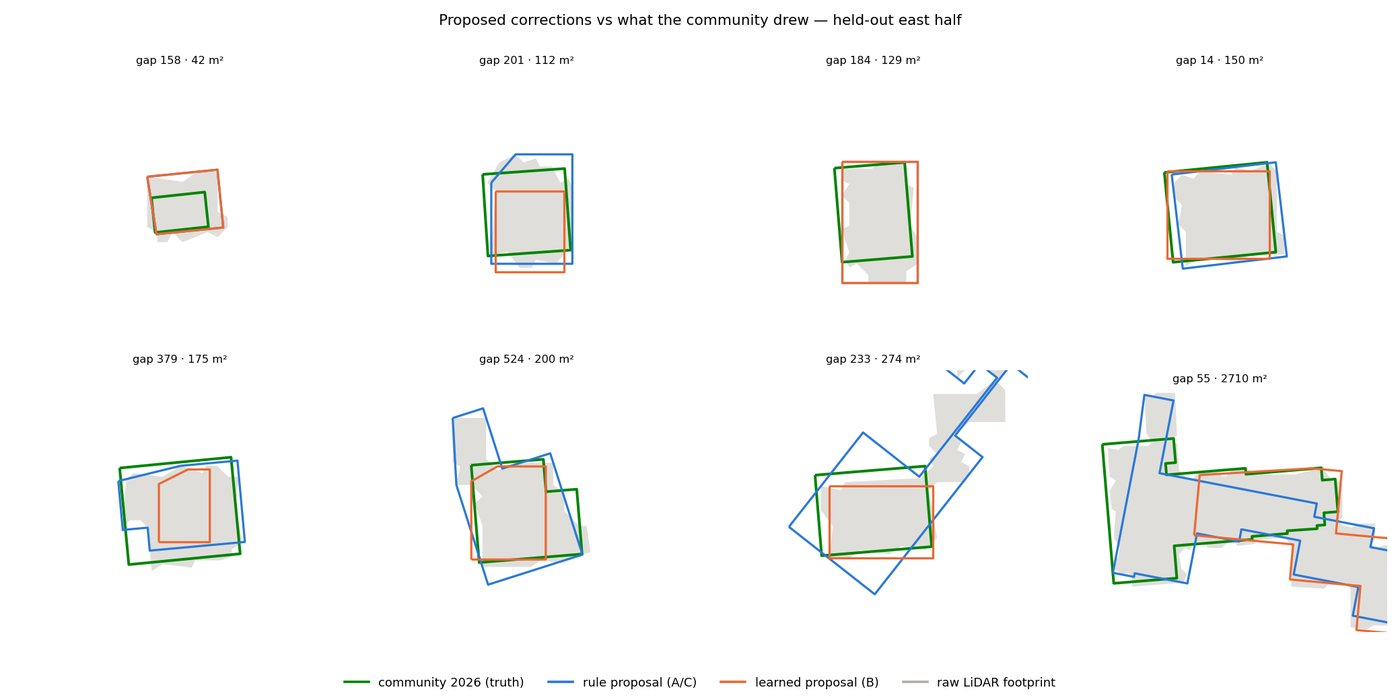

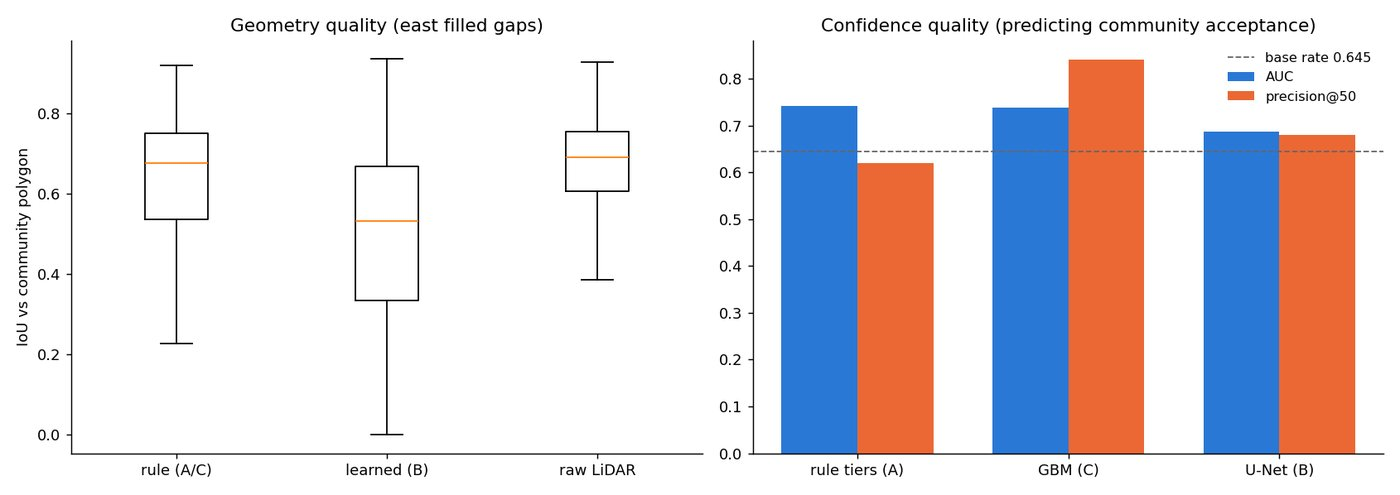

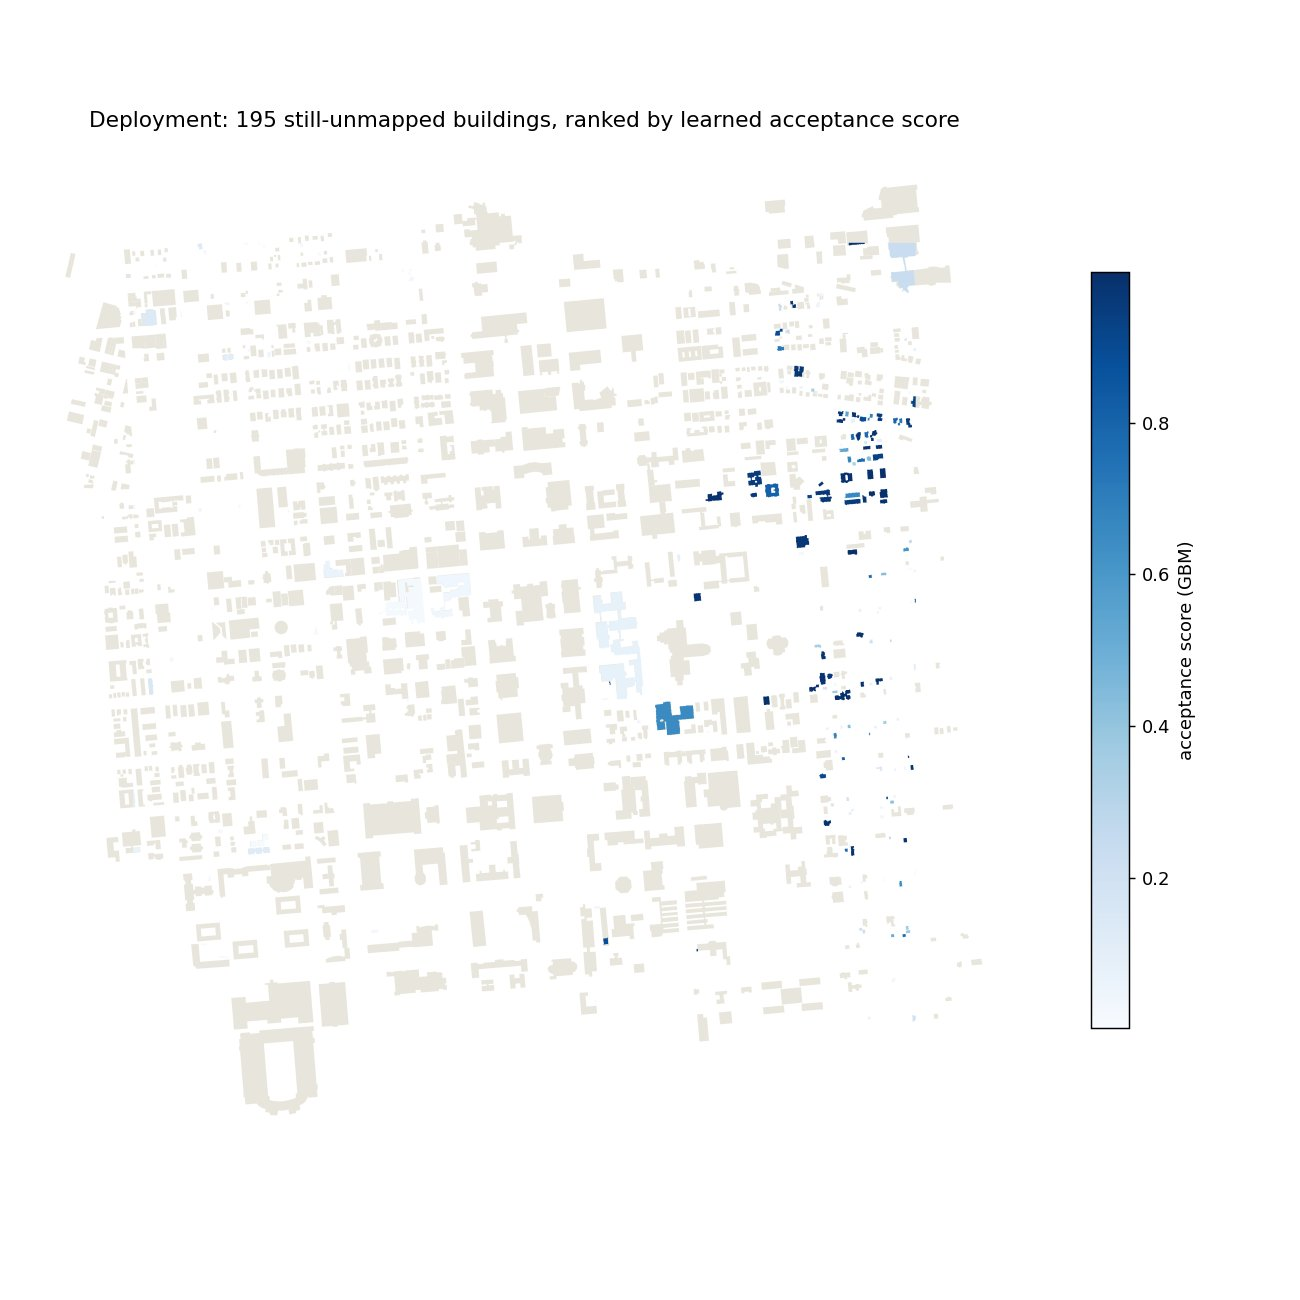

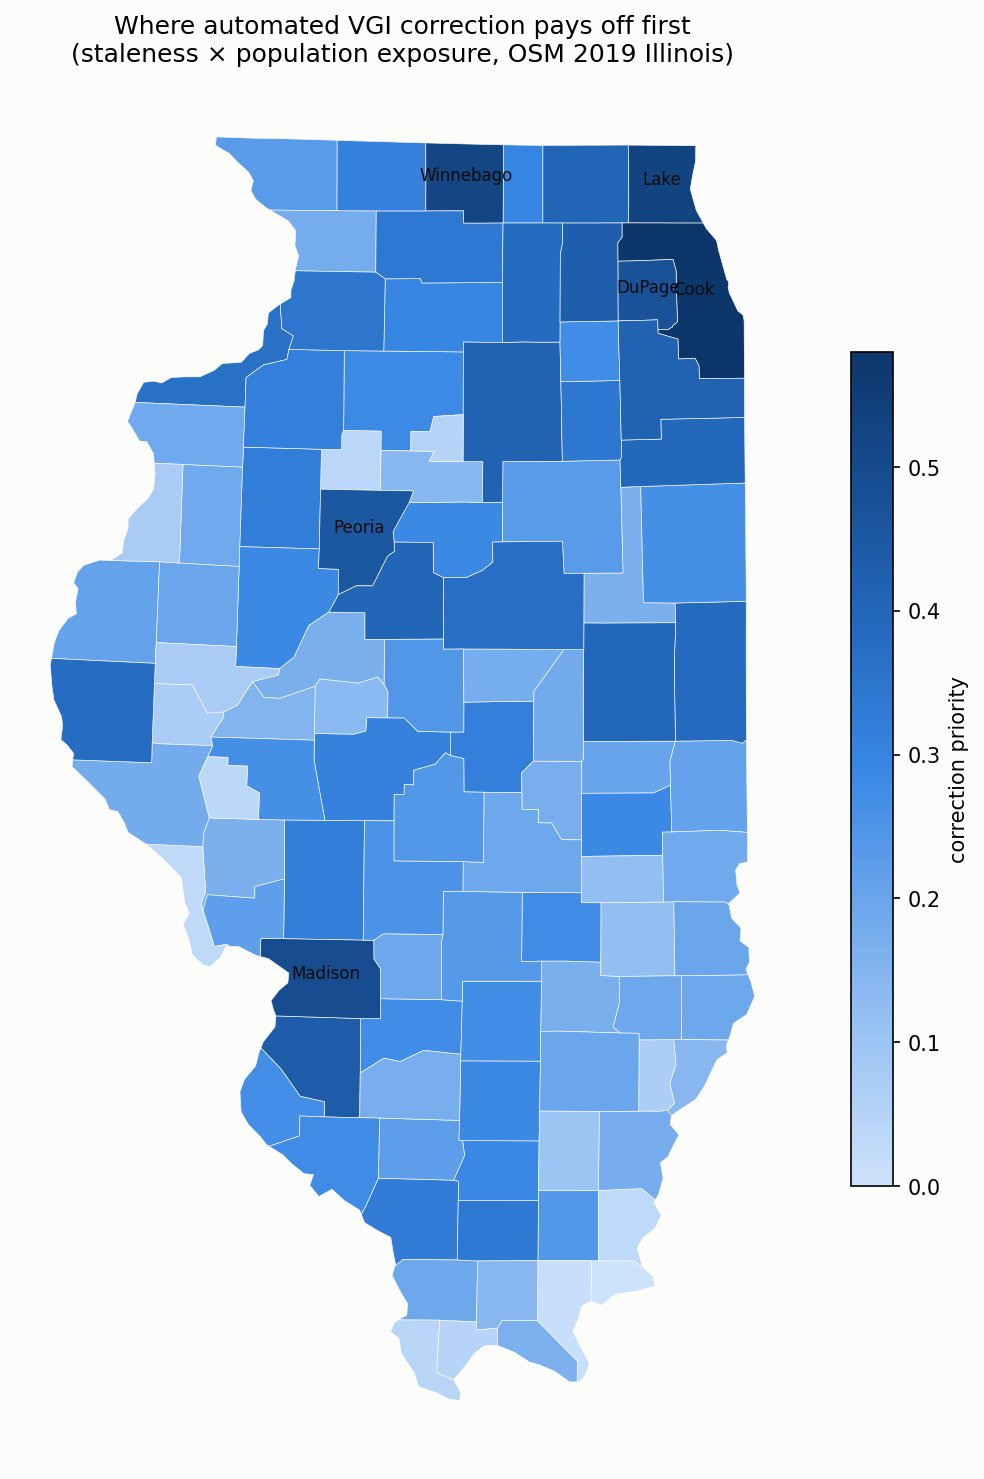

{
  "geometry_east_filled": {
    "rule (A/C)": {
      "n": 269,
      "median_iou": 0.677,
      "mean_iou": 0.642,
      "median_centroid_off_m": 1.45,
      "median_area_ratio": 1.15
    },
    "learned (B)": {
      "n": 269,
      "median_iou": 0.532,
      "mean_iou": 0.497,
      "median_centroid_off_m": 1.67,
      "median_area_ratio": 0.7
    },
    "raw LiDAR": {
      "n": 269,
      "median_iou": 0.691,
      "mean_iou": 0.665,
      "median_centroid_off_m": 1.39,
      "median_area_ratio": 1.04
    }
  },
  "confidence_east": {
    "auc": {
      "rule_tiers": 0.742,
      "gbm": 0.738,
      "unet_mask": 0.687
    },
    "precision_at_50": {
      "rule_tiers": 0.62,
      "gbm": 0.84,
      "unet_mask": 0.68
    },
    "base_rate": 0.645,
    "eval_gaps": 417
  }
}


In [18]:
show("results/uiuc_campus/correction/proposal_gallery.png",
     "results/uiuc_campus/correction/benchmark_summary.png",
     "results/uiuc_campus/correction/deployment_map.png",
     "results/statewide_il/deploy_priority.png")
jshow("results/uiuc_campus/correction/correction_benchmark.json")

### Reading the correction benchmark

- **Geometry:** the rule pipeline reaches median IoU ≈ 0.68 against community
  polygons — and the *raw LiDAR footprint* is marginally better (≈ 0.69):
  regularization trades a little overlap for OSM-style clean right angles. The
  U-Net (trained on only 83 west-half gaps) trails at ≈ 0.59 — with this little
  data, rules beat learning for geometry.
- **Confidence:** for *ranking* proposals the learned scorer wins where it counts —
  precision@50 ≈ 0.84 vs 0.62 for rule tiers (base rate 0.65). If a mapper only
  reviews 50 proposals, the GBM hands them a far cleaner queue.
- **Best combination = approach C**: rule geometry + learned acceptance score.
- The deployment map ranks the 195 still-unmapped buildings; statewide, stale
  urban counties (Cook, Lake, Winnebago) top the correction-priority list.

## 10 · Stage 8 — Does the method generalize? A second region (Colorado Springs)

Everything so far ran on one university campus. This stage repeats the detect →
validate loop on a **2 × 2 km Colorado Springs residential tile** — a deliberately
harder test of generality:

- **Minimal LiDAR classification.** The CS delivery has only ground/non-ground
  classes (no ASPRS building/vegetation), at ~5 pts/m² vs the campus's ~20.
  `src/region_detection.py` swaps the class evidence for two sensor-derived
  signals — NAIP NDVI and the multi-return echo fraction (canopies return multiple
  echoes, roofs do not) — while keeping the identical grid, morphology and
  thresholds, so the numbers stay cross-region comparable.
- **Different landscape and climate.** Semi-arid suburbia instead of a midwest
  campus. One caveat travels with that: dry ground depresses NDVI, inflating the
  NAIP impervious class — the forward road-support metric is unaffected, but the
  reverse "explained paved" fraction is not comparable across regions.
- **Same evaluation.** OSM 2019 clip (703 buildings, attribute-preserving) vs the
  RS detection; temporal validation against the current OSM snapshot
  (`data/colorado_springs/osm_buildings_2026.geojson`, fetched via
  `src/fetch_osm_current.py` with the CS bounding box).

In [19]:
run("src/prepare_data.py", "colorado")
run("src/region_detection.py", "data/colorado_springs/cs_lidar_2km.laz",
    "data/colorado_springs/NAIP_image.tif", "results/colorado_springs/detection")
run("src/naip_segmentation.py", "data/colorado_springs/NAIP_image.tif",
    "results/colorado_springs/detection/buildings.geojson", "results/colorado_springs/naip")
run("src/vgi_comparison.py", "data/colorado_springs/osm_buildings_2019.geojson",
    "results/colorado_springs/comparison", "results/colorado_springs/detection/buildings.geojson")
run("src/road_comparison.py", "results/colorado_springs/naip/naip_paved.tif",
    "results/colorado_springs/comparison/roads", "2019=data/colorado_springs/osm_roads_2019.geojson")
run("src/temporal_validation.py", "results/colorado_springs/detection/buildings.geojson",
    "data/colorado_springs/osm_buildings_2019.geojson",
    "data/colorado_springs/osm_buildings_2026.geojson",
    "results/colorado_springs/comparison/temporal")

$ python src/prepare_data.py colorado
[colorado]
  already present: data/colorado_springs/cs_lidar_2km.laz
  already present: data/colorado_springs/NAIP_image.tif
data ready
$ python src/region_detection.py data/colorado_springs/cs_lidar_2km.laz data/colorado_springs/NAIP_image.tif results/colorado_springs/detection


/Users/yifn/Downloads/uiuc_campus_lidar/src/region_detection.py:123: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  bmask = binary_closing(bmask, disk(2))
/Users/yifn/Downloads/uiuc_campus_lidar/src/region_detection.py:124: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bmask = remove_small_holes(bmask, area_threshold=min_cells)


/Users/yifn/Downloads/uiuc_campus_lidar/src/region_detection.py:125: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bmask = remove_small_objects(bmask, min_size=min_cells)


[1/5] rasterizing 20,221,590 pts -> 4154x4154 @ 0.5 m
[2/5] building DTM (nearest-fill of ground minima)
[3/5] warping NAIP NDVI onto the LiDAR grid
[4/5] detecting buildings (elevated, non-vegetation)
      -> 2122 buildings
[5/5] detecting trees
      -> 12138 trees
{
  "resolution_m": 0.5,
  "grid": [
    4154,
    4154
  ],
  "vegetation_source": "NDVI+echo",
  "buildings": {
    "count": 2122,
    "total_footprint_m2": 602276.3,
    "median_height_m": 3.3
  },
  "trees": {
    "count": 12138
  }
}
$ python src/naip_segmentation.py data/colorado_springs/NAIP_image.tif results/colorado_springs/detection/buildings.geojson results/colorado_springs/naip


/Users/yifn/Downloads/uiuc_campus_lidar/src/naip_segmentation.py:61: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  imperv = remove_small_objects(remove_small_holes(imperv, 60), 40)
/Users/yifn/Downloads/uiuc_campus_lidar/src/naip_segmentation.py:61: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  imperv = remov

...

NAIP tile 3462x3463 px @ 0.60 m, EPSG:6350
{
  "resolution_m": 0.6,
  "vegetation_pct": 28.6,
  "impervious_pct": 70.4,
  "building_m2": 582840,
  "paved_m2": 2260139,
  "vegetation_m2": 1232241,
  "note": "building = NAIP impervious \u2229 LiDAR footprint; paved = roads+parking+sidewalks"
}
done -> results/colorado_springs/naip
$ python src/vgi_comparison.py data/colorado_springs/osm_buildings_2019.geojson results/colorado_springs/comparison results/colorado_springs/detection/buildings.geojson


/Users/yifn/Downloads/uiuc_campus_lidar/src/vgi_comparison.py:99: RuntimeWarning: invalid value encountered in divide
  comp = np.where(tot > 0, mat/tot, np.nan)


LiDAR buildings: 2122   reference: 701
{
  "reference": "osm_buildings_2019.geojson",
  "iou_threshold": 0.3,
  "lidar_buildings": 2122,
  "reference_buildings": 701,
  "matched": 618,
  "completeness_count": 0.2912,
  "completeness_area": 0.6764,
  "reference_commission": 0.1027,
  "lidar_only_omissions": 1504,
  "reference_only": 72,
  "median_matched_iou": 0.701
}
done -> results/colorado_springs/comparison
$ python src/road_comparison.py results/colorado_springs/naip/naip_paved.tif results/colorado_springs/comparison/roads 2019=data/colorado_springs/osm_roads_2019.geojson


{
  "2019": {
    "snapshot": "2019",
    "segments": 140,
    "length_km": 44.6,
    "support_threshold": 0.5,
    "supported_segments": 0.9929,
    "supported_length": 0.999,
    "median_support": 0.894,
    "paved_explained": 0.2011
  }
}
done -> results/colorado_springs/comparison/roads
$ python src/temporal_validation.py results/colorado_springs/detection/buildings.geojson data/colorado_springs/osm_buildings_2019.geojson data/colorado_springs/osm_buildings_2026.geojson results/colorado_springs/comparison/temporal


{
  "lidar_buildings": 2122,
  "osm2019_buildings": 701,
  "osm2026_buildings": 2783,
  "mapped_2019": 618,
  "gaps_2019": 1504,
  "filled_by_2026": 1125,
  "still_unmapped": 379,
  "gap_fill_rate": 0.748,
  "completeness_2019_count": 0.2912,
  "completeness_2026_count": 0.8129,
  "completeness_2019_area": 0.6764,
  "completeness_2026_area": 0.9188
}
done -> results/colorado_springs/comparison/temporal


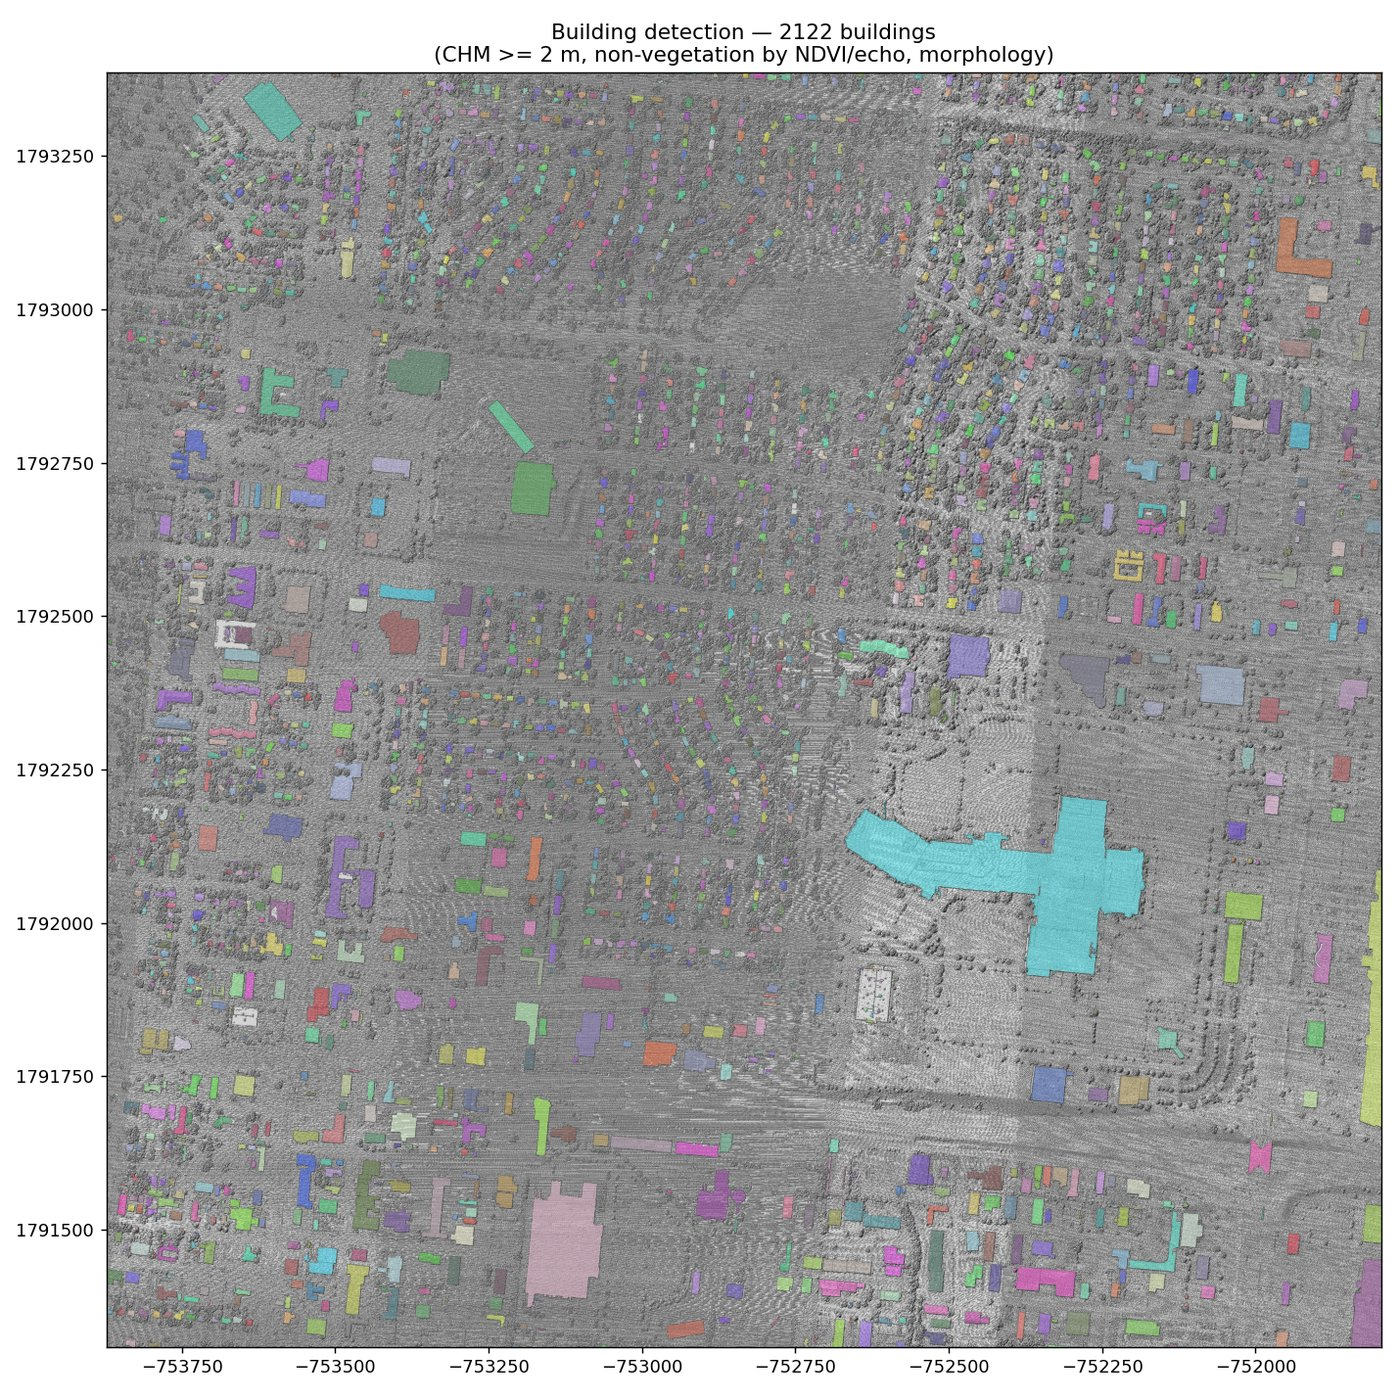

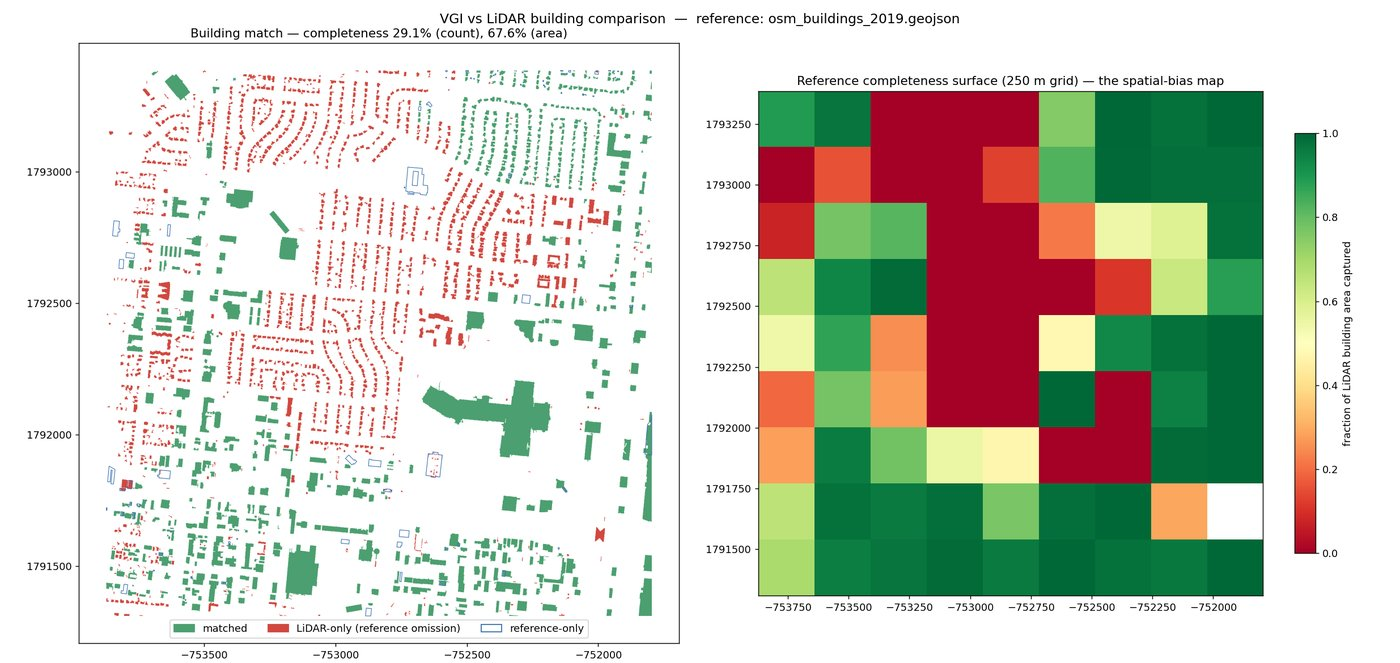

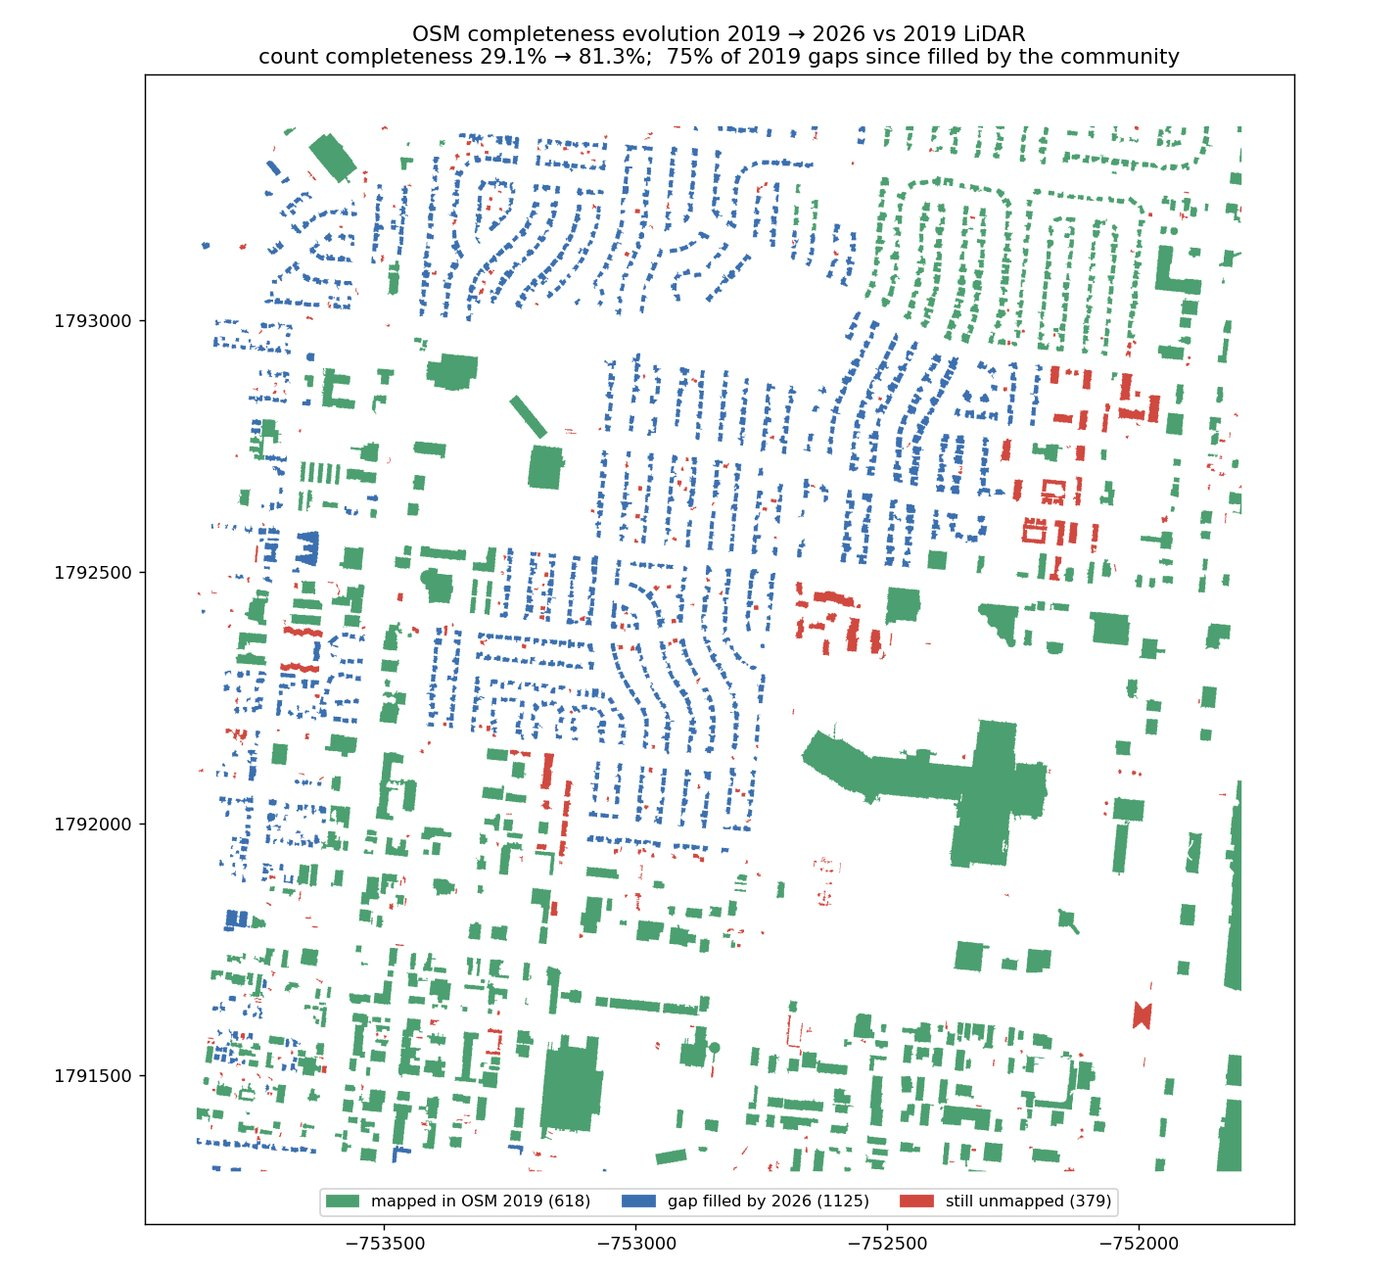

{
  "reference": "osm_buildings_2019.geojson",
  "iou_threshold": 0.3,
  "lidar_buildings": 2122,
  "reference_buildings": 701,
  "matched": 618,
  "completeness_count": 0.2912,
  "completeness_area": 0.6764,
  "reference_commission": 0.1027,
  "lidar_only_omissions": 1504,
  "reference_only": 72,
  "median_matched_iou": 0.701
}
{
  "lidar_buildings": 2122,
  "osm2019_buildings": 701,
  "osm2026_buildings": 2783,
  "mapped_2019": 618,
  "gaps_2019": 1504,
  "filled_by_2026": 1125,
  "still_unmapped": 379,
  "gap_fill_rate": 0.748,
  "completeness_2019_count": 0.2912,
  "completeness_2026_count": 0.8129,
  "completeness_2019_area": 0.6764,
  "completeness_2026_area": 0.9188
}


In [20]:
show("results/colorado_springs/detection/buildings_detected.png",
     "results/colorado_springs/comparison/comparison_map.png",
     "results/colorado_springs/comparison/temporal/temporal_evolution.png")
jshow("results/colorado_springs/comparison/comparison_summary.json")
jshow("results/colorado_springs/comparison/temporal/temporal_summary.json")

### Cross-region result

| | UIUC campus | Colorado Springs |
|---|---|---|
| LiDAR-detected buildings | 1,312 | 2,122 (NDVI+echo variant) |
| OSM 2019 completeness (count / area) | 58.3% / 79.4% | **29.1% / 67.6%** |
| gaps community-filled by 2026 | 64% | **74.8%** |
| completeness today (count / area) | 81.9% / 91.8% | 81.3% / 91.9% |
| road length NAIP-supported | 99.6% (major) | 99.9% |

The residential tile is under-mapped **twice as badly** as the campus in 2019 —
entire subdivisions were absent — and the community itself has since confirmed
three quarters of our detections. Road geometry is near-perfect in both regions:
across two very different landscapes, **the bias lives in buildings and
attributes, not in the road network**. The detection variant transfers without
retuning, which is the prerequisite for pointing this pipeline at the statewide
priority counties from Stage 7.

### Correction on the second region

The correction stage reruns with a single region argument — same scripts, same
splits, same metrics. Colorado Springs supplies **821 west-half community-filled
gaps for training and 304 held-out east-half gaps for evaluation** — roughly ten
times the campus's label budget — which flips the geometry contest:

In [21]:
RUN_LEARNED = globals().get("RUN_LEARNED", False)   # False if the config cell was not (re-)run
run("src/propose_geometry.py", "colorado_springs")
run("src/acceptance_scorer.py", "colorado_springs")
if RUN_LEARNED:
    run("src/propose_learned.py", "colorado_springs")
else:
    print("RUN_LEARNED = False -> using the committed learned proposals")
run("src/correction_benchmark.py", "colorado_springs")

$ python src/propose_geometry.py colorado_springs


{
  "gaps": 1504,
  "filled": 1125,
  "still_unmapped": 379,
  "regularized": 1438,
  "hull_fallbacks": 66,
  "east_eval_filled": 304
}
$ python src/acceptance_scorer.py colorado_springs


/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/shapely/constructive.py:1353: RuntimeWarning: invalid value encountered in oriented_envelope
  return lib.oriented_envelope(geometry, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/shapely/constructive.py:1353: RuntimeWarning: divide by zero encountered in oriented_envelope
  return lib.oriented_envelope(geometry, **kwargs)


{
  "train_gaps": 1048,
  "train_filled": 821,
  "eval_gaps": 456,
  "eval_filled": 304,
  "auc_rule_tiers": 0.656,
  "auc_gbm": 0.985,
  "precision_at_50_rule": 0.46,
  "precision_at_50_gbm": 0.98,
  "base_rate_eval": 0.667,
  "gbm_feature_importance": {
    "area_m2": 0.679,
    "height_m": 0.053,
    "imperv_frac": 0.025,
    "dist_road": 0.115,
    "neigh_completeness": 0.089,
    "fill_ratio": 0.04
  }
}
$ python src/propose_learned.py colorado_springs


/Users/yifn/Downloads/uiuc_campus_lidar/src/propose_learned.py:135: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  tot += float(loss) * len(b)


device=mps  train patches=6568 (from 821 west gaps)
epoch 10/40  bce=0.0716
epoch 20/40  bce=0.0591
epoch 30/40  bce=0.054
epoch 40/40  bce=0.0502
{
  "device": "mps",
  "epochs": 40,
  "train_patches": 6568,
  "train_gaps": 821,
  "east_pixel_iou_median": 0.768,
  "fallbacks": 209
}


$ python src/correction_benchmark.py colorado_springs


{
  "geometry_east_filled": {
    "rule (A/C)": {
      "n": 304,
      "median_iou": 0.662,
      "mean_iou": 0.647,
      "median_centroid_off_m": 1.73,
      "median_area_ratio": 0.87
    },
    "learned (B)": {
      "n": 304,
      "median_iou": 0.769,
      "mean_iou": 0.75,
      "median_centroid_off_m": 0.9,
      "median_area_ratio": 1.05
    },
    "raw LiDAR": {
      "n": 304,
      "median_iou": 0.678,
      "mean_iou": 0.655,
      "median_centroid_off_m": 1.59,
      "median_area_ratio": 0.82
    }
  },
  "confidence_east": {
    "auc": {
      "rule_tiers": 0.656,
      "gbm": 0.985,
      "unet_mask": 0.79
    },
    "precision_at_50": {
      "rule_tiers": 0.46,
      "gbm": 1.0,
      "unet_mask": 0.6
    },
    "base_rate": 0.667,
    "eval_gaps": 456
  }
}
figures -> /Users/yifn/Downloads/uiuc_campus_lidar/results/colorado_springs/correction


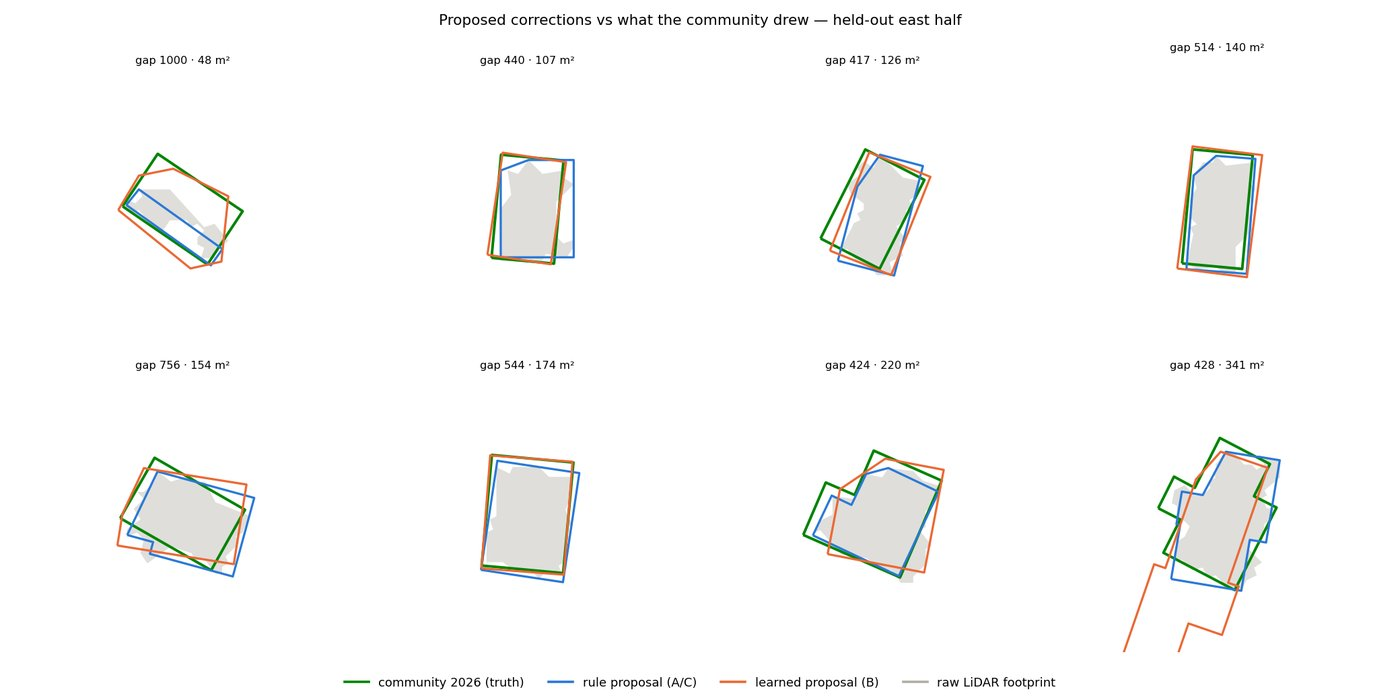

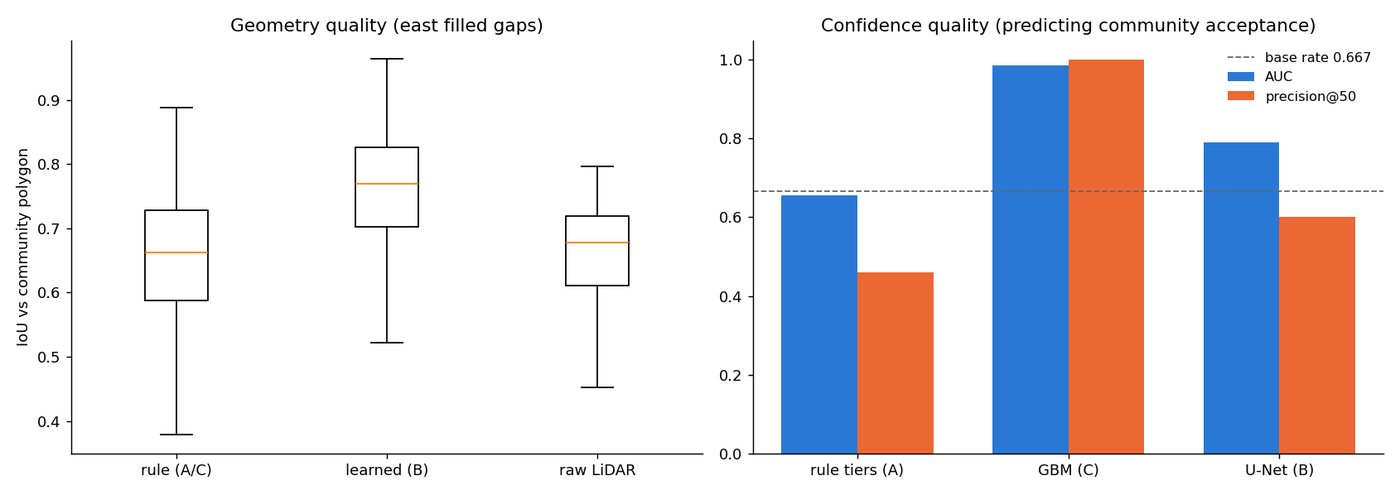

{
  "geometry_east_filled": {
    "rule (A/C)": {
      "n": 304,
      "median_iou": 0.662,
      "mean_iou": 0.647,
      "median_centroid_off_m": 1.73,
      "median_area_ratio": 0.87
    },
    "learned (B)": {
      "n": 304,
      "median_iou": 0.769,
      "mean_iou": 0.75,
      "median_centroid_off_m": 0.9,
      "median_area_ratio": 1.05
    },
    "raw LiDAR": {
      "n": 304,
      "median_iou": 0.678,
      "mean_iou": 0.655,
      "median_centroid_off_m": 1.59,
      "median_area_ratio": 0.82
    }
  },
  "confidence_east": {
    "auc": {
      "rule_tiers": 0.656,
      "gbm": 0.985,
      "unet_mask": 0.79
    },
    "precision_at_50": {
      "rule_tiers": 0.46,
      "gbm": 1.0,
      "unet_mask": 0.6
    },
    "base_rate": 0.667,
    "eval_gaps": 456
  }
}


In [22]:
show("results/colorado_springs/correction/proposal_gallery.png",
     "results/colorado_springs/correction/benchmark_summary.png")
jshow("results/colorado_springs/correction/correction_benchmark.json")

### The training-data effect — winners flip with label volume

| | UIUC campus (83 training gaps) | Colorado Springs (821 training gaps) |
|---|---|---|
| geometry median IoU | rules **0.677** > U-Net 0.589 | U-Net **0.769** > rules 0.662 |
| median centroid offset | rules 1.45 m | U-Net **0.90 m** |
| confidence AUC | tiers 0.742 ≈ GBM 0.738 | GBM **0.985** ≫ tiers 0.656 |
| precision@50 | GBM **0.84** (base 0.65) | GBM **1.00** (base 0.67) |

With scarce labels, hand-written regularization rules are the safer geometry
choice; once the community has confirmed enough examples, the U-Net learns local
building style and overtakes them — and the learned acceptance scorer dominates in
both regions, hitting a perfect top-50 on Colorado Springs. Practical recipe:
**rules first, swap in learning as confirmations accumulate; always rank the
review queue with the learned scorer.** The 379 still-unmapped Colorado Springs
buildings ship as ranked proposals in
`results/colorado_springs/correction/deployment_map.png`.

## 11 · Summary

| Finding | Evidence |
|---|---|
| OSM omissions are real and spatially structured | 58.3 % building completeness; < 0.3 on the residential strip (Stage 4) |
| RS consensus detects them years early | 64 % of 2019 gaps community-filled by 2026 (Stage 4) |
| Roads: geometry fine, attributes poor | 91–99.6 % pavement support (Stage 5) vs 3.3 % maxspeed statewide (Stage 6) |
| The method generalizes across regions | CS: 29.1%→81.3% completeness, 74.8% gap-fill confirmation with only ground-classified LiDAR (Stage 8) |
| Correction winners flip with label volume | CS (821 labels): U-Net geometry IoU 0.769 beats rules; GBM scorer AUC 0.985, precision@50 = 1.00 (Stage 8) |
| Quality follows contributors, not need | recency ρ = 0.70 with pop. density; TIGER-stale downstate; Sangamon hotspot (Stage 6) |

**Correction (Stage 7):** detection is now closed into a propose→score→prioritize
loop — rule geometry + a learned acceptance scorer (approach C) yields review-ready
proposals (median IoU 0.68 vs community polygons, precision@50 0.84), with a
statewide priority map saying where to deploy first. Natural extensions:
socioeconomic covariates (ACS income/education) in the Stage 6 regression, and
packaging the 195 outstanding proposals as a MapRoulette challenge.

**Data credits** — USGS 3DEP LiDAR (public domain) · USDA NAIP (public domain) ·
© OpenStreetMap contributors (ODbL) · US Census Bureau. Code: MIT
([LICENSE](https://github.com/rayford295/vgi-spatial-bias/blob/main/LICENSE)).

*Project repository: <https://github.com/rayford295/vgi-spatial-bias> — an I-GUIDE
Summer School 2026 project.*